# 20 Newsgroups Pipeline

Notebook nay duoc chia thanh 3 phan lon dung nhu solution flow:
1. `Load Data`
2. `EDA`
3. `Preprocessing`


## Setup

Block nay import cac thu vien can dung cho viec load data, EDA, chia tap va preprocessing cho cac nhanh model.


In [1]:
from collections import Counter
from pathlib import Path
import json
import math
import re

import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 40)


Block nay thiet lap root project, thu muc luu du lieu local va cac tham so co dinh su dung xuyen suot notebook.


In [2]:
workspace_root = Path.cwd()
notebook_dir = workspace_root if workspace_root.name == "Assignment1" else workspace_root / "Assignment1"
project_root = notebook_dir

data_dir = notebook_dir / "data" / "classification" / "text"
raw_dir = data_dir / "raw"
clean_dir = data_dir / "clean"
processed_dir = data_dir / "processed"
for folder in [data_dir, raw_dir, clean_dir, processed_dir]:
    folder.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
SHORT_TEXT_THRESHOLD = 5
BILSTM_MIN_FREQ = 2
BILSTM_MAX_LEN_CAP = 400
DISTILBERT_MAX_LEN_CAP = 256
DISTILBERT_MODEL_NAME = "distilbert-base-uncased"

print(f"Notebook directory: {notebook_dir}")
print(f"Project root: {project_root}")
print(f"Data directory: {data_dir}")
print(f"Raw directory: {raw_dir}")
print(f"Clean directory: {clean_dir}")
print(f"Processed directory: {processed_dir}")


Notebook directory: /home/godminhkhoa/Document/Deep-Learning-Assignment/Assignment1
Project root: /home/godminhkhoa/Document/Deep-Learning-Assignment/Assignment1
Data directory: /home/godminhkhoa/Document/Deep-Learning-Assignment/Assignment1/data/classification/text
Raw directory: /home/godminhkhoa/Document/Deep-Learning-Assignment/Assignment1/data/classification/text/raw
Clean directory: /home/godminhkhoa/Document/Deep-Learning-Assignment/Assignment1/data/classification/text/clean
Processed directory: /home/godminhkhoa/Document/Deep-Learning-Assignment/Assignment1/data/classification/text/processed


## 1. Load Data

Block nay tai va luu 2 phien ban du lieu:
- `raw`: giu nguyen metadata de phuc vu EDA va audit
- `clean`: loai bo `headers`, `footers`, `quotes` de dung cho preprocessing va modeling


In [3]:
def dataset_to_records(dataset, split_name):
    records = []
    filenames = getattr(dataset, "filenames", [None] * len(dataset.data))
    for idx, (text, target, filename) in enumerate(zip(dataset.data, dataset.target, filenames)):
        records.append(
            {
                "sample_id": idx,
                "split": split_name,
                "filename": str(filename) if filename is not None else None,
                "text": text,
                "target": int(target),
                "target_name": dataset.target_names[int(target)],
            }
        )
    return records


def write_jsonl(records, path):
    with path.open("w", encoding="utf-8") as f:
        for record in records:
            f.write(json.dumps(record, ensure_ascii=False) + "\n")


raw_train_dataset = fetch_20newsgroups(subset="train", shuffle=True, random_state=RANDOM_STATE)
raw_test_dataset = fetch_20newsgroups(subset="test", shuffle=True, random_state=RANDOM_STATE)

clean_train_dataset = fetch_20newsgroups(
    subset="train",
    shuffle=True,
    random_state=RANDOM_STATE,
    remove=("headers", "footers", "quotes"),
)
clean_test_dataset = fetch_20newsgroups(
    subset="test",
    shuffle=True,
    random_state=RANDOM_STATE,
    remove=("headers", "footers", "quotes"),
)

raw_train_records = dataset_to_records(raw_train_dataset, "train_raw")
raw_test_records = dataset_to_records(raw_test_dataset, "test_raw")
clean_train_records = dataset_to_records(clean_train_dataset, "train_clean")
clean_test_records = dataset_to_records(clean_test_dataset, "test_clean")

paths = {
    "raw_train": raw_dir / "20newsgroups_train_raw.jsonl",
    "raw_test": raw_dir / "20newsgroups_test_raw.jsonl",
    "clean_train": clean_dir / "20newsgroups_train_clean.jsonl",
    "clean_test": clean_dir / "20newsgroups_test_clean.jsonl",
}

for key, records in {
    "raw_train": raw_train_records,
    "raw_test": raw_test_records,
    "clean_train": clean_train_records,
    "clean_test": clean_test_records,
}.items():
    write_jsonl(records, paths[key])

train_raw_df = pd.DataFrame(raw_train_records)
test_raw_df = pd.DataFrame(raw_test_records)
train_clean_df = pd.DataFrame(clean_train_records)
test_clean_df = pd.DataFrame(clean_test_records)

print(f"Raw train shape  : {train_raw_df.shape}")
print(f"Raw test shape   : {test_raw_df.shape}")
print(f"Clean train shape: {train_clean_df.shape}")
print(f"Clean test shape : {test_clean_df.shape}")
print(f"Saved raw train  : {paths['raw_train']}")
print(f"Saved raw test   : {paths['raw_test']}")
print(f"Saved clean train: {paths['clean_train']}")
print(f"Saved clean test : {paths['clean_test']}")


Raw train shape  : (11314, 6)
Raw test shape   : (7532, 6)
Clean train shape: (11314, 6)
Clean test shape : (7532, 6)
Saved raw train  : /home/godminhkhoa/Document/Deep-Learning-Assignment/Assignment1/data/classification/text/raw/20newsgroups_train_raw.jsonl
Saved raw test   : /home/godminhkhoa/Document/Deep-Learning-Assignment/Assignment1/data/classification/text/raw/20newsgroups_test_raw.jsonl
Saved clean train: /home/godminhkhoa/Document/Deep-Learning-Assignment/Assignment1/data/classification/text/clean/20newsgroups_train_clean.jsonl
Saved clean test : /home/godminhkhoa/Document/Deep-Learning-Assignment/Assignment1/data/classification/text/clean/20newsgroups_test_clean.jsonl


## 2. EDA

Phan nay chi de xem du lieu, audit raw va nhin tac dong cua cleaned corpus.

Block nay in truc tiep cac raw sample de nhin ro metadata leakage, quote va signature trong du lieu goc.


In [4]:
def print_raw_sample(df, sample_id):
    row = df.loc[df["sample_id"] == sample_id].iloc[0]
    print(f"===== RAW SAMPLE {sample_id} =====")
    print(f"label_id: {row['target']}")
    print(f"label_name: {row['target_name']}")
    print(f"filename: {row['filename']}")
    print(f"word_count: {len(row['text'].split())}")
    print(f"char_count: {len(row['text'])}")
    print(row["text"])
    print("\n")


for raw_sample_id in range(5):
    print_raw_sample(train_raw_df, raw_sample_id)


===== RAW SAMPLE 0 =====
label_id: 7
label_name: rec.autos
filename: /home/godminhkhoa/scikit_learn_data/20news_home/20news-bydate-train/rec.autos/102994
word_count: 123
char_count: 721
From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







===== RAW SAMPLE 1 =====
label_id: 4
label_name: comp.sys.mac.hardware
filename: /home/god

Block nay dat raw va clean canh nhau tren mot vai sample de thay tac dong cua buoc remove metadata.


In [5]:
sample_indices = [0, 1, 2, 3, 4]
preview_df = pd.DataFrame(
    {
        "sample_id": sample_indices,
        "target_name": train_raw_df.loc[sample_indices, "target_name"].values,
        "raw_word_count": train_raw_df.loc[sample_indices, "text"].str.split().str.len().values,
        "clean_word_count": train_clean_df.loc[sample_indices, "text"].str.split().str.len().values,
        "raw_preview": train_raw_df.loc[sample_indices, "text"].str.replace("\n", " ", regex=False).str.slice(0, 220).values,
        "clean_preview": train_clean_df.loc[sample_indices, "text"].str.replace("\n", " ", regex=False).str.slice(0, 220).values,
    }
)
display(preview_df)


,sample_id,target_name,raw_word_count,clean_word_count,raw_preview,clean_preview
0,0,rec.autos,123,91,"From: lerxst@wam.umd.edu (where's my thing) Subject: WHAT car is this!? Nntp-Posting-Host: rac3.wam.umd.edu Organization: University of Maryland, College Pa...","I was wondering if anyone out there could enlighten me on this car I saw the other day. It was a 2-door sports car, looked to be from the late 60s/ early 70..."
1,1,comp.sys.mac.hardware,123,90,"From: guykuo@carson.u.washington.edu (Guy Kuo) Subject: SI Clock Poll - Final Call Summary: Final call for SI clock reports Keywords: SI,acceleration,clock,...",A fair number of brave souls who upgraded their SI clock oscillator have shared their experiences for this poll. Please send a brief message detailing your ...
2,2,comp.sys.mac.hardware,339,307,From: twillis@ec.ecn.purdue.edu (Thomas E Willis) Subject: PB questions... Organization: Purdue University Engineering Computer Network Distribution: usa Li...,"well folks, my mac plus finally gave up the ghost this weekend after starting life as a 512k way back in 1985. sooo, i'm in the market for a new machine a ..."
3,3,comp.graphics,113,15,From: jgreen@amber (Joe Green) Subject: Re: Weitek P9000 ? Organization: Harris Computer Systems Division Lines: 14 Distribution: world NNTP-Posting-Host: a...,Do you have Weitek's address/phone number? I'd like to get some information about this chip.
4,4,sci.space,171,72,"From: jcm@head-cfa.harvard.edu (Jonathan McDowell) Subject: Re: Shuttle Launch Question Organization: Smithsonian Astrophysical Observatory, Cambridge, MA, ...","From article <C5owCB.n3p@world.std.com>, by tombaker@world.std.com (Tom A Baker): My understanding is that the 'expected errors' are basically known bugs ..."


Block nay thong ke do dai van ban truoc va sau clean, dong thoi kiem tra phan bo class de dam bao label distribution khong bi lech.


In [6]:
eda_stats = pd.DataFrame(
    {
        "raw_train_char_count": train_raw_df["text"].str.len().describe(),
        "clean_train_char_count": train_clean_df["text"].str.len().describe(),
        "raw_train_word_count": train_raw_df["text"].str.split().str.len().describe(),
        "clean_train_word_count": train_clean_df["text"].str.split().str.len().describe(),
    }
)
display(eda_stats)

class_distribution = pd.concat(
    [
        train_raw_df["target_name"].value_counts().sort_index().rename("raw_train_count"),
        train_clean_df["target_name"].value_counts().sort_index().rename("clean_train_count"),
    ],
    axis=1,
)
display(class_distribution)


,raw_train_char_count,clean_train_char_count,raw_train_word_count,clean_train_word_count
count,11314.000000,11314.000000,11314.000000,11314.000000
mean,1949.310058,1218.135496,287.470126,185.827382
std,4159.979767,4038.256477,541.482636,523.971647
min,125.000000,0.000000,14.000000,0.000000
25%,753.250000,237.000000,108.000000,40.000000
50%,1178.000000,491.000000,176.000000,83.000000
75%,1881.000000,984.750000,293.000000,167.000000
max,75154.000000,74878.000000,11821.000000,11765.000000


,raw_train_count,clean_train_count
target_name,,
alt.atheism,480,480
comp.graphics,584,584
comp.os.ms-windows.misc,591,591
comp.sys.ibm.pc.hardware,590,590
comp.sys.mac.hardware,578,578
comp.windows.x,593,593
misc.forsale,585,585
rec.autos,594,594
rec.motorcycles,598,598


Block nay audit cleaned corpus qua top unigram va cac tu khoa metadata nhu `subject`, `organization`, `posting`, `host`.


In [7]:
def audit_tokens(text):
    tokens = re.findall(r"[a-z]+", text.lower())
    return [token for token in tokens if token not in ENGLISH_STOP_WORDS and len(token) > 2]


token_counter = Counter()
for text in train_clean_df["text"]:
    token_counter.update(audit_tokens(text))

top_unigrams_after_remove = pd.DataFrame(token_counter.most_common(25), columns=["token", "frequency"])
display(top_unigrams_after_remove)

metadata_terms = ["subject", "organization", "posting", "host"]
metadata_term_counts = pd.DataFrame(
    {
        "term": metadata_terms,
        "raw_train_doc_count": [int(train_raw_df['text'].str.contains(term, case=False, regex=False).sum()) for term in metadata_terms],
        "clean_train_doc_count": [int(train_clean_df['text'].str.contains(term, case=False, regex=False).sum()) for term in metadata_terms],
    }
)
display(metadata_term_counts)


,token,frequency
0,max,4680
1,people,4104
2,like,3967
3,don,3886
4,just,3757
5,know,3492
6,use,3181
7,think,3014
8,time,2977
9,does,2787


,term,raw_train_doc_count,clean_train_doc_count
0,subject,11314,476
1,organization,10882,244
2,posting,5154,383
3,host,4964,225


## 3. Preprocessing

Tu phan nay moi bat dau preprocessing cho modeling.

Block nay thuc hien common text normalization o muc nhe, tao cac cot audit truoc sau clean, log so mau rong va qua ngan.


In [8]:
def normalize_text_basic(text):
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = text.strip()
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"[ \t]{2,}", " ", text)
    text = re.sub(r" *\n *", "\n", text)
    return text.strip()


def add_normalized_columns(df):
    out = df.copy()
    out["text_normalized"] = out["text"].map(normalize_text_basic)
    out["char_count_before"] = out["text"].str.len()
    out["char_count_after"] = out["text_normalized"].str.len()
    out["word_count_before"] = out["text"].str.split().str.len()
    out["word_count_after"] = out["text_normalized"].str.split().str.len()
    out["is_empty_after_clean"] = out["word_count_after"] == 0
    out["is_short_after_clean"] = out["word_count_after"] < SHORT_TEXT_THRESHOLD
    out["model_text"] = out["text_normalized"]
    return out


train_pre_df = add_normalized_columns(train_clean_df)
test_pre_df = add_normalized_columns(test_clean_df)

train_model_df = train_pre_df.loc[~train_pre_df["is_empty_after_clean"]].copy().reset_index(drop=True)
test_model_df = test_pre_df.loc[~test_pre_df["is_empty_after_clean"]].copy().reset_index(drop=True)

model_ready_paths = {
    "train": processed_dir / "20newsgroups_train_model_ready.jsonl",
    "test": processed_dir / "20newsgroups_test_model_ready.jsonl",
}
write_jsonl(train_model_df.to_dict(orient="records"), model_ready_paths["train"])
write_jsonl(test_model_df.to_dict(orient="records"), model_ready_paths["test"])

preprocessing_log = pd.DataFrame(
    {
        "split": ["train_clean", "test_clean"],
        "rows_before_drop_empty": [len(train_pre_df), len(test_pre_df)],
        "empty_after_clean": [int(train_pre_df['is_empty_after_clean'].sum()), int(test_pre_df['is_empty_after_clean'].sum())],
        f"short_lt_{SHORT_TEXT_THRESHOLD}": [int(train_pre_df['is_short_after_clean'].sum()), int(test_pre_df['is_short_after_clean'].sum())],
        "rows_used_for_modeling": [len(train_model_df), len(test_model_df)],
    }
)
display(preprocessing_log)

before_after_examples = pd.DataFrame(
    {
        "sample_id": [0, 1, 2],
        "clean_preview": train_clean_df.loc[[0, 1, 2], 'text'].str.replace("\n", " ", regex=False).str.slice(0, 220).values,
        "normalized_preview": train_pre_df.loc[[0, 1, 2], 'text_normalized'].str.replace("\n", " ", regex=False).str.slice(0, 220).values,
    }
)
display(before_after_examples)


,split,rows_before_drop_empty,empty_after_clean,short_lt_5,rows_used_for_modeling
0,train_clean,11314,300,410,11014
1,test_clean,7532,215,292,7317


,sample_id,clean_preview,normalized_preview
0,0,"I was wondering if anyone out there could enlighten me on this car I saw the other day. It was a 2-door sports car, looked to be from the late 60s/ early 70...","I was wondering if anyone out there could enlighten me on this car I saw the other day. It was a 2-door sports car, looked to be from the late 60s/ early 70..."
1,1,A fair number of brave souls who upgraded their SI clock oscillator have shared their experiences for this poll. Please send a brief message detailing your ...,A fair number of brave souls who upgraded their SI clock oscillator have shared their experiences for this poll. Please send a brief message detailing your ...
2,2,"well folks, my mac plus finally gave up the ghost this weekend after starting life as a 512k way back in 1985. sooo, i'm in the market for a new machine a ...","well folks, my mac plus finally gave up the ghost this weekend after starting life as a 512k way back in 1985. sooo, i'm in the market for a new machine a b..."


Block nay chia du lieu thanh `train`, `val`, `test` bang stratified split va log class distribution cua tung tap.


In [9]:
train_df, val_df = train_test_split(
    train_model_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_model_df["target"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_model_df.reset_index(drop=True)

split_paths = {
    "train": processed_dir / "20newsgroups_train_split.jsonl",
    "val": processed_dir / "20newsgroups_val_split.jsonl",
    "test": processed_dir / "20newsgroups_test_split.jsonl",
}

write_jsonl(train_df.to_dict(orient="records"), split_paths["train"])
write_jsonl(val_df.to_dict(orient="records"), split_paths["val"])
write_jsonl(test_df.to_dict(orient="records"), split_paths["test"])

def class_distribution_table(df, split_name):
    table = df["target_name"].value_counts().sort_index().rename(split_name).to_frame()
    table["ratio"] = (table[split_name] / len(df)).round(4)
    return table


distribution_table = pd.concat(
    [
        class_distribution_table(train_df, "train_count"),
        class_distribution_table(val_df, "val_count"),
        class_distribution_table(test_df, "test_count"),
    ],
    axis=1,
).fillna(0)
display(distribution_table)

print(f"Train size: {len(train_df):,}")
print(f"Val size  : {len(val_df):,}")
print(f"Test size : {len(test_df):,}")


,train_count,ratio,val_count,ratio,test_count,ratio
target_name,,,,,,
alt.atheism,374,0.0424,94,0.0427,311,0.0425
comp.graphics,457,0.0519,114,0.0517,384,0.0525
comp.os.ms-windows.misc,454,0.0515,114,0.0517,379,0.0518
comp.sys.ibm.pc.hardware,462,0.0524,116,0.0527,386,0.0528
comp.sys.mac.hardware,446,0.0506,112,0.0508,371,0.0507
comp.windows.x,473,0.0537,118,0.0536,391,0.0534
misc.forsale,462,0.0524,115,0.0522,382,0.0522
rec.autos,450,0.0511,112,0.0508,375,0.0513
rec.motorcycles,466,0.0529,117,0.0531,386,0.0528


Train size: 8,811
Val size  : 2,203
Test size : 7,317


Block nay chuan bi input cho nhanh BiLSTM: tokenizer word-level, build vocab tren train, numericalization, padding, truncation va logging.


In [10]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"


def bilstm_tokenize(text):
    return re.findall(r"[a-z0-9']+", text.lower())


train_df["bilstm_tokens"] = train_df["model_text"].map(bilstm_tokenize)
val_df["bilstm_tokens"] = val_df["model_text"].map(bilstm_tokenize)
test_df["bilstm_tokens"] = test_df["model_text"].map(bilstm_tokenize)

train_token_lengths = train_df["bilstm_tokens"].map(len)
bilstm_max_len = int(math.ceil(train_token_lengths.quantile(0.95)))
bilstm_max_len = max(16, min(bilstm_max_len, BILSTM_MAX_LEN_CAP))

bilstm_counter = Counter()
for tokens in train_df["bilstm_tokens"]:
    bilstm_counter.update(tokens)

vocab_tokens = sorted([token for token, freq in bilstm_counter.items() if freq >= BILSTM_MIN_FREQ])
token_to_id = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for token in vocab_tokens:
    token_to_id[token] = len(token_to_id)


def encode_bilstm(tokens, token_to_id, max_len):
    ids = []
    unk_count = 0
    for token in tokens:
        token_id = token_to_id.get(token, token_to_id[UNK_TOKEN])
        if token_id == token_to_id[UNK_TOKEN]:
            unk_count += 1
        ids.append(token_id)
    original_length = len(ids)
    truncated = original_length > max_len
    ids = ids[:max_len]
    padded_ids = ids + [token_to_id[PAD_TOKEN]] * (max_len - len(ids))
    return {
        "input_ids": padded_ids,
        "original_length": original_length,
        "truncated": truncated,
        "unk_count": unk_count,
    }


for split_df in [train_df, val_df, test_df]:
    encoded = split_df["bilstm_tokens"].map(lambda tokens: encode_bilstm(tokens, token_to_id, bilstm_max_len))
    split_df["bilstm_input_ids"] = encoded.map(lambda x: x["input_ids"])
    split_df["bilstm_original_length"] = encoded.map(lambda x: x["original_length"])
    split_df["bilstm_truncated"] = encoded.map(lambda x: x["truncated"])
    split_df["bilstm_unk_count"] = encoded.map(lambda x: x["unk_count"])


bilstm_log = pd.DataFrame(
    {
        "metric": [
            "vocab_size",
            "min_freq",
            "max_len",
            "avg_train_encoded_length",
            "train_truncation_rate",
            "val_truncation_rate",
            "test_truncation_rate",
            "train_unk_ratio",
        ],
        "value": [
            len(token_to_id),
            BILSTM_MIN_FREQ,
            bilstm_max_len,
            round(train_df["bilstm_original_length"].mean(), 2),
            round(train_df["bilstm_truncated"].mean(), 4),
            round(val_df["bilstm_truncated"].mean(), 4),
            round(test_df["bilstm_truncated"].mean(), 4),
            round(train_df["bilstm_unk_count"].sum() / max(1, train_df["bilstm_original_length"].sum()), 4),
        ],
    }
)
display(bilstm_log)

bilstm_examples = pd.DataFrame(
    {
        "text_preview": train_df["model_text"].head(3).str.replace("\n", " ", regex=False).str.slice(0, 120),
        "tokens": train_df["bilstm_tokens"].head(3),
        "input_ids_head": train_df["bilstm_input_ids"].head(3).map(lambda ids: ids[:20]),
    }
)
display(bilstm_examples)


,metric,value
0,vocab_size,41600.0000
1,min_freq,2.0000
2,max_len,400.0000
3,avg_train_encoded_length,219.2000
4,train_truncation_rate,0.0813
5,val_truncation_rate,0.0831
6,test_truncation_rate,0.0802
7,train_unk_ratio,0.0260


,text_preview,tokens,input_ids_head
0,I think it is an ESDI controller if you need the doco i can help you. Stefan,"[i, think, it, is, an, esdi, controller, if, you, need, the, doco, i, can, help, you, stefan]","[19615, 36833, 21058, 20976, 6137, 15230, 11398, 19801, 41240, 26285, 36730, 1, 19615, 9307, 18846, 41240, 35240, 0, 0, 0]"
1,I remember one he hit circa 1976 at Wrigley Field that went across the street (in dead center field) and hit a house on,"[i, remember, one, he, hit, circa, 1976, at, wrigley, field, that, went, across, the, street, in, dead, center, field, and, hit, a, house, on, the, roof, he...","[19615, 31500, 27420, 18718, 19063, 10209, 2011, 6962, 40398, 16241, 36722, 39855, 5331, 36730, 35444, 20089, 12487, 9725, 16241, 6189]"
2,": Regardless of people's hidden motivations, the stated reasons for many : wars include religion. Of course you can alwa","[regardless, of, people's, hidden, motivations, the, stated, reasons, for, many, wars, include, religion, of, course, you, can, always, claim, that, the, re...","[31321, 27238, 28522, 18978, 25566, 36730, 35168, 31037, 16677, 24034, 39662, 20139, 31461, 27238, 11668, 41240, 9307, 6012, 10301, 36722]"


Block nay chuan bi input cho nhanh DistilBERT bang tokenizer pretrained, tao `input_ids`, `attention_mask` va log token length stats.


In [11]:
distilbert_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL_NAME)

train_token_lengths = train_df["model_text"].map(
    lambda text: len(distilbert_tokenizer(text, truncation=False, padding=False)["input_ids"])
)
distilbert_max_length = int(math.ceil(train_token_lengths.quantile(0.95)))
distilbert_max_length = max(32, min(distilbert_max_length, DISTILBERT_MAX_LEN_CAP))


def add_distilbert_features(df, tokenizer, max_length):
    token_lengths = df["model_text"].map(lambda text: len(tokenizer(text, truncation=False, padding=False)["input_ids"]))
    encoded = tokenizer(
        df["model_text"].tolist(),
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_attention_mask=True,
    )
    out = df.copy()
    out["distilbert_token_length"] = token_lengths
    out["distilbert_truncated"] = token_lengths > max_length
    out["distilbert_input_ids"] = encoded["input_ids"]
    out["distilbert_attention_mask"] = encoded["attention_mask"]
    return out


train_df = add_distilbert_features(train_df, distilbert_tokenizer, distilbert_max_length)
val_df = add_distilbert_features(val_df, distilbert_tokenizer, distilbert_max_length)
test_df = add_distilbert_features(test_df, distilbert_tokenizer, distilbert_max_length)

distilbert_log = pd.DataFrame(
    {
        "metric": [
            "tokenizer_name",
            "max_length",
            "avg_train_token_length",
            "train_truncation_rate",
            "val_truncation_rate",
            "test_truncation_rate",
        ],
        "value": [
            DISTILBERT_MODEL_NAME,
            distilbert_max_length,
            round(train_df["distilbert_token_length"].mean(), 2),
            round(train_df["distilbert_truncated"].mean(), 4),
            round(val_df["distilbert_truncated"].mean(), 4),
            round(test_df["distilbert_truncated"].mean(), 4),
        ],
    }
)
display(distilbert_log)

distilbert_examples = []
for text in train_df["model_text"].head(3):
    tokens = distilbert_tokenizer.tokenize(text)[:25]
    token_ids = distilbert_tokenizer.convert_tokens_to_ids(tokens)
    distilbert_examples.append(
        {
            "text_preview": text.replace("\n", " ")[:120],
            "tokens": tokens,
            "token_ids": token_ids,
        }
    )

display(pd.DataFrame(distilbert_examples))


Token indices sequence length is longer than the specified maximum sequence length for this model (589 > 512). Running this sequence through the model will result in indexing errors


,metric,value
0,tokenizer_name,distilbert-base-uncased
1,max_length,256
2,avg_train_token_length,375.02
3,train_truncation_rate,0.2445
4,val_truncation_rate,0.2429
5,test_truncation_rate,0.239


,text_preview,tokens,token_ids
0,I think it is an ESDI controller if you need the doco i can help you. Stefan,"[i, think, it, is, an, es, ##di, controller, if, you, need, the, doc, ##o, i, can, help, you, ., stefan]","[1045, 2228, 2009, 2003, 2019, 9686, 4305, 11486, 2065, 2017, 2342, 1996, 9986, 2080, 1045, 2064, 2393, 2017, 1012, 8852]"
1,I remember one he hit circa 1976 at Wrigley Field that went across the street (in dead center field) and hit a house on,"[i, remember, one, he, hit, circa, 1976, at, wr, ##ig, ##ley, field, that, went, across, the, street, (, in, dead, center, field, ), and, hit]","[1045, 3342, 2028, 2002, 2718, 12800, 3299, 2012, 23277, 8004, 3051, 2492, 2008, 2253, 2408, 1996, 2395, 1006, 1999, 2757, 2415, 2492, 1007, 1998, 2718]"
2,": Regardless of people's hidden motivations, the stated reasons for many : wars include religion. Of course you can alwa","[:, regardless, of, people, ', s, hidden, motivation, ##s, ,, the, stated, reasons, for, many, :, wars, include, religion, ., of, course, you, can, always]","[1024, 7539, 1997, 2111, 1005, 1055, 5023, 14354, 2015, 1010, 1996, 3090, 4436, 2005, 2116, 1024, 5233, 2421, 4676, 1012, 1997, 2607, 2017, 2064, 2467]"


Block nay tong hop cac quyet dinh preprocessing cuoi cung va ghi metadata pipeline ra file de su dung lai.


In [12]:
final_decisions = [
    "Raw data chi dung de audit va EDA.",
    "Main modeling corpus dung remove=(headers, footers, quotes).",
    "Common cleaning giu nhe: strip + normalize whitespace.",
    "Empty samples sau clean duoc log va drop khoi modeling set.",
    "Near-empty samples duoc log rieng de theo doi, khong aggressive drop ngay.",
    "Train/Val split dung stratified split voi random_state co dinh.",
    "BiLSTM dung lowercase + regex tokenizer + vocab build tren train + <pad>/<unk>.",
    "DistilBERT dung pretrained tokenizer va preprocessing toi gian.",
    "Tat ca cac buoc preprocess deu co logging de justify bang EDA.",
]

for idx, decision in enumerate(final_decisions, start=1):
    print(f"{idx}. {decision}")

metadata = {
    "dataset_name": "20 Newsgroups",
    "random_state": RANDOM_STATE,
    "short_text_threshold": SHORT_TEXT_THRESHOLD,
    "bilstm_min_freq": BILSTM_MIN_FREQ,
    "bilstm_max_len": bilstm_max_len,
    "distilbert_model_name": DISTILBERT_MODEL_NAME,
    "distilbert_max_length": distilbert_max_length,
    "paths": {name: str(path.relative_to(project_root)) for name, path in {
        "raw_train": paths["raw_train"],
        "raw_test": paths["raw_test"],
        "clean_train": paths["clean_train"],
        "clean_test": paths["clean_test"],
        "model_ready_train": model_ready_paths["train"],
        "model_ready_test": model_ready_paths["test"],
        "split_train": split_paths["train"],
        "split_val": split_paths["val"],
        "split_test": split_paths["test"],
    }.items()},
}

metadata_path = processed_dir / "20newsgroups_pipeline_metadata.json"
with metadata_path.open("w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"Saved pipeline metadata: {metadata_path}")


1. Raw data chi dung de audit va EDA.
2. Main modeling corpus dung remove=(headers, footers, quotes).
3. Common cleaning giu nhe: strip + normalize whitespace.
4. Empty samples sau clean duoc log va drop khoi modeling set.
5. Near-empty samples duoc log rieng de theo doi, khong aggressive drop ngay.
6. Train/Val split dung stratified split voi random_state co dinh.
7. BiLSTM dung lowercase + regex tokenizer + vocab build tren train + <pad>/<unk>.
8. DistilBERT dung pretrained tokenizer va preprocessing toi gian.
9. Tat ca cac buoc preprocess deu co logging de justify bang EDA.
Saved pipeline metadata: /home/godminhkhoa/Document/Deep-Learning-Assignment/Assignment1/data/classification/text/processed/20newsgroups_pipeline_metadata.json


## 4. Train Models

Phan nay di tiep tu cleaned split -> TF-IDF baseline -> neural prototype -> BiLSTM.


Block nay import cac thu vien can thiet cho baseline co dien va train model PyTorch. Cac import nay duoc dat rieng de phan train co the chay doc lap.


In [13]:
import os
import time
import random
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence


@dataclass
class TrainCFG:
    seed: int = 42
    tfidf_max_features: int = 50000
    tfidf_ngram_range: tuple = (1, 2)
    tfidf_min_df: int = 2
    tfidf_max_df: float = 0.95
    tfidf_C: float = 4.0
    tfidf_max_iter: int = 2000

    lowercase: bool = True
    min_freq: int = 2
    max_len: int = 384

    proto_embed_dim: int = 128
    proto_dropout: float = 0.3
    proto_batch_size: int = 64
    proto_lr: float = 1e-3
    proto_weight_decay: float = 1e-4
    proto_epochs: int = 5

    bilstm_embed_dim: int = 200
    bilstm_hidden_size: int = 96
    bilstm_num_layers: int = 1
    bilstm_bidirectional: bool = True
    bilstm_dropout: float = 0.4
    bilstm_batch_size: int = 64
    bilstm_lr: float = 1e-3
    bilstm_weight_decay: float = 1e-4
    bilstm_grad_clip: float = 1.0
    bilstm_epochs: int = 6

    proto_patience: int = 2
    bilstm_patience: int = 2

    num_workers: int = 0
    pad_token: str = "<pad>"
    unk_token: str = "<unk>"
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


train_cfg = TrainCFG()
print(train_cfg)
print("Device:", train_cfg.device)


TrainCFG(seed=42, tfidf_max_features=50000, tfidf_ngram_range=(1, 2), tfidf_min_df=2, tfidf_max_df=0.95, tfidf_C=4.0, tfidf_max_iter=2000, lowercase=True, min_freq=2, max_len=384, proto_embed_dim=128, proto_dropout=0.3, proto_batch_size=64, proto_lr=0.001, proto_weight_decay=0.0001, proto_epochs=5, bilstm_embed_dim=200, bilstm_hidden_size=96, bilstm_num_layers=1, bilstm_bidirectional=True, bilstm_dropout=0.4, bilstm_batch_size=64, bilstm_lr=0.001, bilstm_weight_decay=0.0001, bilstm_grad_clip=1.0, bilstm_epochs=6, proto_patience=2, bilstm_patience=2, num_workers=0, pad_token='<pad>', unk_token='<unk>', device='cuda')
Device: cuda


Block nay co dinh seed de baseline va cac model PyTorch cho ket qua on dinh hon giua cac lan chay.


In [14]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(train_cfg.seed)


Block nay chot ro 3 tap text/label dung cho train. Day la diem bat dau cho toan bo qua trinh huan luyen.


In [15]:
train_texts = train_df["model_text"].tolist()
val_texts = val_df["model_text"].tolist()
test_texts = test_df["model_text"].tolist()

y_train = train_df["target"].to_numpy()
y_val = val_df["target"].to_numpy()
y_test = test_df["target"].to_numpy()

label_names = train_df[["target", "target_name"]].drop_duplicates().sort_values("target")["target_name"].tolist()
num_classes = len(label_names)

print("Train:", len(train_texts))
print("Val:", len(val_texts))
print("Test:", len(test_texts))
print("Num classes:", num_classes)
assert num_classes == 20


Train: 8811
Val: 2203
Test: 7317
Num classes: 20


Block nay chay mot vong post-preprocessing audit ngan de xac nhan cleaned text da on truoc khi train.


In [16]:
audit_preview = pd.DataFrame({
    "sample_id": [0, 1, 2],
    "raw_preview": train_raw_df.loc[[0, 1, 2], "text"].str.replace("\n", " ", regex=False).str.slice(0, 220).values,
    "clean_preview": train_clean_df.loc[[0, 1, 2], "text"].str.replace("\n", " ", regex=False).str.slice(0, 220).values,
    "normalized_preview": train_pre_df.loc[[0, 1, 2], "text_normalized"].str.replace("\n", " ", regex=False).str.slice(0, 220).values,
})
display(audit_preview)

print("Train empty after clean:", int(train_pre_df["is_empty_after_clean"].sum()))
print("Test empty after clean :", int(test_pre_df["is_empty_after_clean"].sum()))
print("Train word count stats after clean:")
display(train_pre_df["word_count_after"].describe().to_frame("word_count_after"))

post_token_counter = Counter()
for text in train_model_df["model_text"]:
    post_token_counter.update(audit_tokens(text))

display(pd.DataFrame(post_token_counter.most_common(20), columns=["token", "freq"]))

metadata_terms = ["subject", "organization", "posting", "host"]
metadata_check = pd.DataFrame({
    "term": metadata_terms,
    "raw_doc_count": [int(train_raw_df["text"].str.contains(term, case=False, regex=False).sum()) for term in metadata_terms],
    "clean_doc_count": [int(train_model_df["model_text"].str.contains(term, case=False, regex=False).sum()) for term in metadata_terms],
})
display(metadata_check)


,sample_id,raw_preview,clean_preview,normalized_preview
0,0,"From: lerxst@wam.umd.edu (where's my thing) Subject: WHAT car is this!? Nntp-Posting-Host: rac3.wam.umd.edu Organization: University of Maryland, College Pa...","I was wondering if anyone out there could enlighten me on this car I saw the other day. It was a 2-door sports car, looked to be from the late 60s/ early 70...","I was wondering if anyone out there could enlighten me on this car I saw the other day. It was a 2-door sports car, looked to be from the late 60s/ early 70..."
1,1,"From: guykuo@carson.u.washington.edu (Guy Kuo) Subject: SI Clock Poll - Final Call Summary: Final call for SI clock reports Keywords: SI,acceleration,clock,...",A fair number of brave souls who upgraded their SI clock oscillator have shared their experiences for this poll. Please send a brief message detailing your ...,A fair number of brave souls who upgraded their SI clock oscillator have shared their experiences for this poll. Please send a brief message detailing your ...
2,2,From: twillis@ec.ecn.purdue.edu (Thomas E Willis) Subject: PB questions... Organization: Purdue University Engineering Computer Network Distribution: usa Li...,"well folks, my mac plus finally gave up the ghost this weekend after starting life as a 512k way back in 1985. sooo, i'm in the market for a new machine a ...","well folks, my mac plus finally gave up the ghost this weekend after starting life as a 512k way back in 1985. sooo, i'm in the market for a new machine a b..."


Train empty after clean: 300
Test empty after clean : 215
Train word count stats after clean:


,word_count_after
count,11314.000000
mean,185.827382
std,523.971647
min,0.000000
25%,40.000000
50%,83.000000
75%,167.000000
max,11765.000000


,token,freq
0,max,4680
1,people,4104
2,like,3967
3,don,3886
4,just,3757
5,know,3492
6,use,3181
7,think,3014
8,time,2977
9,does,2787


,term,raw_doc_count,clean_doc_count
0,subject,11314,476
1,organization,10882,244
2,posting,5154,383
3,host,4964,225


Block nay dinh nghia cac ham metric, report, confusion matrix va bang du doan sai de dung chung cho baseline va model neural.


In [17]:
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }


def print_report_and_cm(y_true, y_pred, labels, title="Confusion Matrix"):
    metrics = compute_metrics(y_true, y_pred)
    print(f"Accuracy : {metrics['accuracy']:.4f}")
    print(f"Macro F1 : {metrics['macro_f1']:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=labels, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
    ax.set_title(title)
    plt.show()


def collect_errors(texts, y_true, y_pred, label_names, max_rows=20):
    rows = []
    for text, yt, yp in zip(texts, y_true, y_pred):
        if yt != yp:
            rows.append({
                "true_id": int(yt),
                "true_label": label_names[yt],
                "pred_id": int(yp),
                "pred_label": label_names[yp],
                "text_preview": text[:300].replace("\n", " "),
            })
    return pd.DataFrame(rows[:max_rows])


Block nay train baseline co dien TF-IDF + Logistic Regression de lay moc tham chieu truoc khi vao neural.


In [18]:
tfidf = TfidfVectorizer(
    lowercase=train_cfg.lowercase,
    max_features=train_cfg.tfidf_max_features,
    ngram_range=train_cfg.tfidf_ngram_range,
    min_df=train_cfg.tfidf_min_df,
    max_df=train_cfg.tfidf_max_df,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(train_texts)
X_val_tfidf = tfidf.transform(val_texts)
X_test_tfidf = tfidf.transform(test_texts)

print("TF-IDF shapes:")
print("Train:", X_train_tfidf.shape)
print("Val  :", X_val_tfidf.shape)
print("Test :", X_test_tfidf.shape)

tfidf_clf = LogisticRegression(
    C=train_cfg.tfidf_C,
    max_iter=train_cfg.tfidf_max_iter,
    solver="lbfgs",
)

start = time.time()
tfidf_clf.fit(X_train_tfidf, y_train)
elapsed = time.time() - start
print(f"TF-IDF baseline trained in {elapsed:.2f} sec")


TF-IDF shapes:
Train: (8811, 50000)
Val  : (2203, 50000)
Test : (7317, 50000)
TF-IDF baseline trained in 8.10 sec


===== TF-IDF + Logistic Regression | VAL =====
Accuracy : 0.7503
Macro F1 : 0.7404

                          precision    recall  f1-score   support

             alt.atheism     0.6778    0.6489    0.6630        94
           comp.graphics     0.6897    0.7018    0.6957       114
 comp.os.ms-windows.misc     0.6639    0.6930    0.6781       114
comp.sys.ibm.pc.hardware     0.6637    0.6466    0.6550       116
   comp.sys.mac.hardware     0.7757    0.7411    0.7580       112
          comp.windows.x     0.8190    0.8051    0.8120       118
            misc.forsale     0.7890    0.7478    0.7679       115
               rec.autos     0.7241    0.7500    0.7368       112
         rec.motorcycles     0.7165    0.7778    0.7459       117
      rec.sport.baseball     0.7581    0.8174    0.7866       115
        rec.sport.hockey     0.8519    0.7863    0.8178       117
               sci.crypt     0.8725    0.7672    0.8165       116
         sci.electronics     0.7059    0.7304    0.7179  

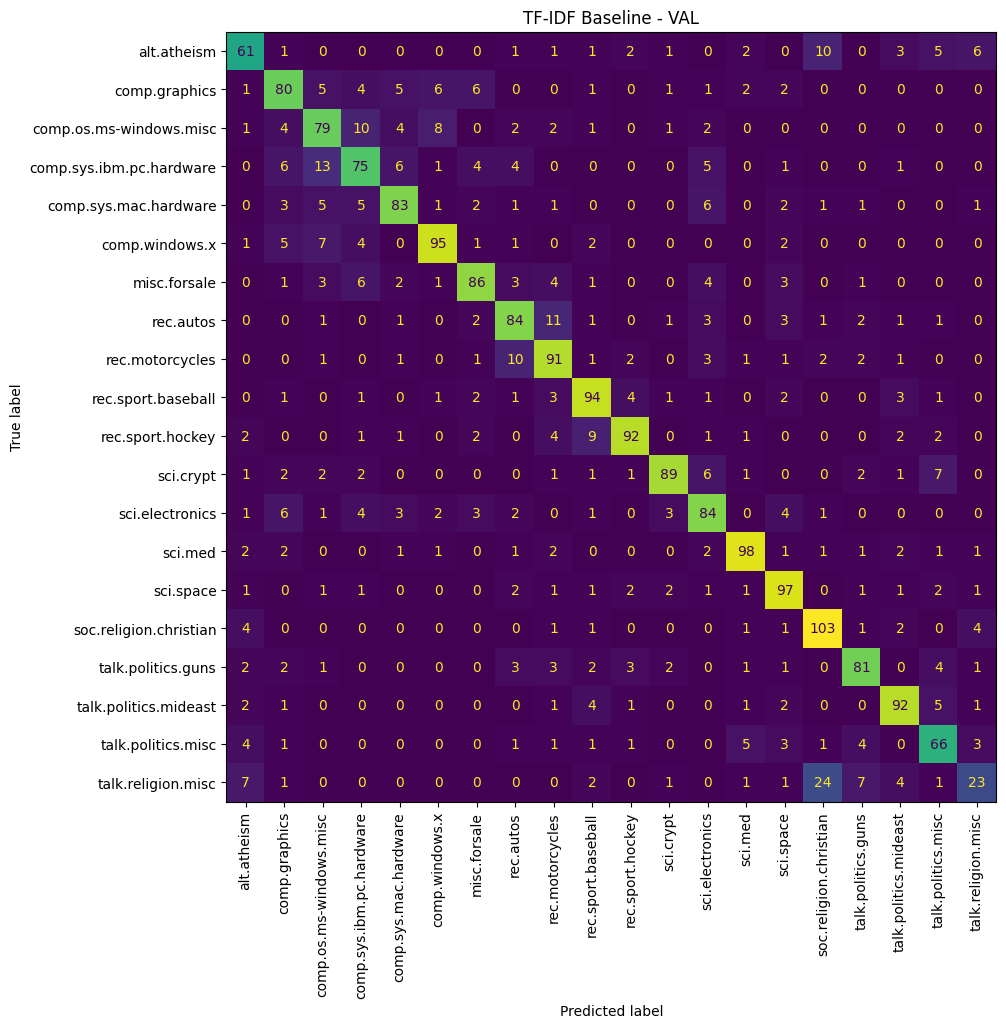

===== TF-IDF + Logistic Regression | TEST =====
Accuracy : 0.6855
Macro F1 : 0.6701

                          precision    recall  f1-score   support

             alt.atheism     0.4904    0.4920    0.4912       311
           comp.graphics     0.5845    0.6667    0.6229       384
 comp.os.ms-windows.misc     0.6549    0.6359    0.6452       379
comp.sys.ibm.pc.hardware     0.6558    0.6269    0.6411       386
   comp.sys.mac.hardware     0.7006    0.6685    0.6841       371
          comp.windows.x     0.7840    0.6777    0.7270       391
            misc.forsale     0.7802    0.8272    0.8030       382
               rec.autos     0.7280    0.7067    0.7172       375
         rec.motorcycles     0.6719    0.7694    0.7174       386
      rec.sport.baseball     0.7659    0.8198    0.7919       383
        rec.sport.hockey     0.8825    0.8667    0.8745       390
               sci.crypt     0.8185    0.6763    0.7406       380
         sci.electronics     0.5550    0.6057    0.5793 

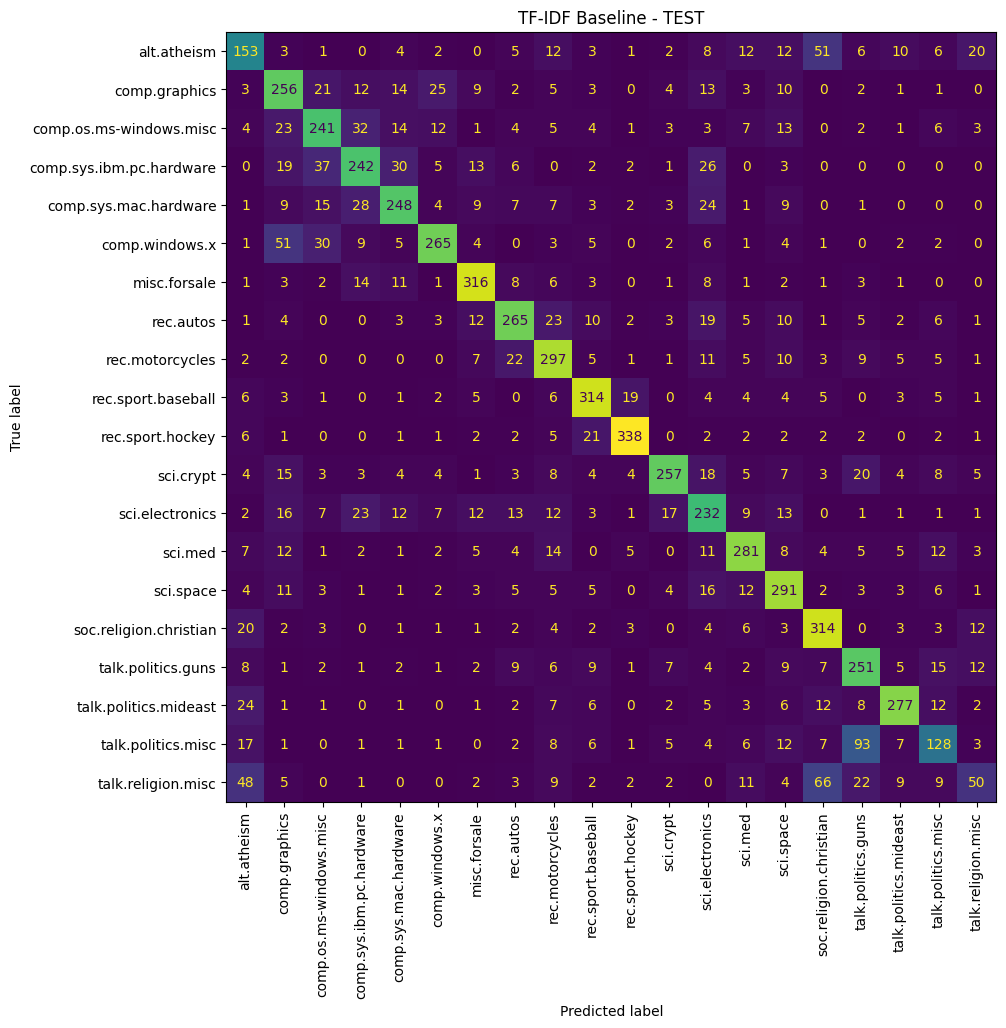

,true_id,true_label,pred_id,pred_label,text_preview
0,7,rec.autos,4,comp.sys.mac.hardware,I am a little confused on all of the models of the 88-89 bonnevilles. I have heard of the LE SE LSE SSE SSEI. Could someone tell me the differences are far ...
1,5,comp.windows.x,1,comp.graphics,"I'm not familiar at all with the format of these ""X-Face:"" thingies, but after seeing them in some folks' headers, I've *got* to *see* them (and maybe make ..."
2,0,alt.atheism,19,talk.religion.misc,"In a word, yes."
3,17,talk.politics.mideast,0,alt.atheism,"They were attacking the Iraqis to drive them out of Kuwait, a country whose citizens have close blood and business ties to Saudi citizens. And me thinks if ..."
4,19,talk.religion.misc,0,alt.atheism,I've just spent two solid months arguing that no such thing as an objective moral system exists.
5,15,soc.religion.christian,10,rec.sport.hockey,"Dishonest money dwindles away, but he who gathers money little by little makes it grow. Proverbs 13:11"
6,15,soc.religion.christian,2,comp.os.ms-windows.misc,"A friend of mine managed to get a copy of a computerised Greek and Hebrew Lexicon called ""The Word Perfect"" (That is not the word processing package WordPer..."
7,5,comp.windows.x,1,comp.graphics,"Most graphics systems I have seen have drawing routines that also specify a color for drawing, like Drawpoint(x,y,color) or Drawline(x1,y1,x2,y2,color) or ..."
8,0,alt.atheism,15,soc.religion.christian,"Probably because it IS rape. So nothing. It may work for some, but not for others: it doesn't give any insight into an overall God or overall truth of a re..."
9,2,comp.os.ms-windows.misc,3,comp.sys.ibm.pc.hardware,"From article <C68uBG.K2w@world.std.com>, by cfw@world.std.com (Christopher F Wroten): Good question. Answer: The EISA bus does move 32 bits rather than ISA'..."


In [19]:
val_pred_tfidf = tfidf_clf.predict(X_val_tfidf)
test_pred_tfidf = tfidf_clf.predict(X_test_tfidf)

print("===== TF-IDF + Logistic Regression | VAL =====")
print_report_and_cm(y_val, val_pred_tfidf, label_names, title="TF-IDF Baseline - VAL")

print("===== TF-IDF + Logistic Regression | TEST =====")
print_report_and_cm(y_test, test_pred_tfidf, label_names, title="TF-IDF Baseline - TEST")

errors_tfidf = collect_errors(test_texts, y_test, test_pred_tfidf, label_names, max_rows=15)
display(errors_tfidf)


Block nay xay tokenizer word-level va vocab chi tu tap train de dung cho prototype va BiLSTM.


In [20]:
TOKEN_PATTERN = re.compile(r"[a-z]+(?:'[a-z]+)?")

def tokenize_words(text: str, lowercase: bool = True):
    if lowercase:
        text = text.lower()
    return TOKEN_PATTERN.findall(text)


def build_vocab(texts, min_freq=2, lowercase=True, specials=("<pad>", "<unk>")):
    counter = Counter()
    for text in texts:
        counter.update(tokenize_words(text, lowercase=lowercase))

    itos = list(specials)
    for token, freq in counter.items():
        if freq >= min_freq:
            itos.append(token)

    stoi = {token: idx for idx, token in enumerate(itos)}
    return stoi, itos, counter


stoi, itos, token_counter = build_vocab(
    train_texts,
    min_freq=train_cfg.min_freq,
    lowercase=train_cfg.lowercase,
    specials=(train_cfg.pad_token, train_cfg.unk_token),
)

PAD_IDX = stoi[train_cfg.pad_token]
UNK_IDX = stoi[train_cfg.unk_token]

print("Vocab size:", len(itos))
print("PAD_IDX:", PAD_IDX, "| UNK_IDX:", UNK_IDX)
display(pd.DataFrame(token_counter.most_common(20), columns=["token", "freq"]))


Vocab size: 35115
PAD_IDX: 0 | UNK_IDX: 1


,token,freq
0,the,84710
1,ax,62298
2,to,42321
3,a,38747
4,of,37560
5,and,34220
6,i,26364
7,in,24867
8,is,24224
9,that,21411


In [21]:
def encode_text(text, stoi, max_len=512, lowercase=True):
    tokens = tokenize_words(text, lowercase=lowercase)
    original_len = len(tokens)
    token_ids = [stoi.get(tok, UNK_IDX) for tok in tokens]
    if len(token_ids) == 0:
        token_ids = [UNK_IDX]
        original_len = 1
    if len(token_ids) > max_len:
        token_ids = token_ids[:max_len]
    return token_ids, original_len


def truncation_stats(texts, stoi, max_len=512, lowercase=True):
    original_lengths = []
    truncated_count = 0
    for text in texts:
        _, orig_len = encode_text(text, stoi, max_len=max_len, lowercase=lowercase)
        original_lengths.append(orig_len)
        if orig_len > max_len:
            truncated_count += 1
    return {
        "num_samples": len(texts),
        "avg_len_before_trunc": float(np.mean(original_lengths)),
        "median_len_before_trunc": float(np.median(original_lengths)),
        "p90_len_before_trunc": float(np.percentile(original_lengths, 90)),
        "max_len_before_trunc": int(np.max(original_lengths)),
        "truncated_samples": truncated_count,
        "truncation_rate": truncated_count / len(texts),
        "max_len_setting": max_len,
    }


train_trunc_stats = truncation_stats(train_texts, stoi, max_len=train_cfg.max_len, lowercase=train_cfg.lowercase)
val_trunc_stats = truncation_stats(val_texts, stoi, max_len=train_cfg.max_len, lowercase=train_cfg.lowercase)

print("Train truncation stats:", train_trunc_stats)
print("Val truncation stats  :", val_trunc_stats)


Train truncation stats: {'num_samples': 8811, 'avg_len_before_trunc': 209.94461468618772, 'median_len_before_trunc': 84.0, 'p90_len_before_trunc': 333.0, 'max_len_before_trunc': 15487, 'truncated_samples': 720, 'truncation_rate': 0.08171603677221655, 'max_len_setting': 384}
Val truncation stats  : {'num_samples': 2203, 'avg_len_before_trunc': 194.2832501134816, 'median_len_before_trunc': 89.0, 'p90_len_before_trunc': 342.0, 'max_len_before_trunc': 14084, 'truncated_samples': 187, 'truncation_rate': 0.08488424875170222, 'max_len_setting': 384}


Block nay tao Dataset va collate function cho prototype va BiLSTM, dong thoi pad cac sequence trong moi batch.


In [22]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, stoi, max_len=512, lowercase=True):
        self.texts = texts
        self.labels = labels
        self.stoi = stoi
        self.max_len = max_len
        self.lowercase = lowercase

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = int(self.labels[idx])
        token_ids, original_len = encode_text(text, self.stoi, max_len=self.max_len, lowercase=self.lowercase)
        return {
            "input_ids": torch.tensor(token_ids, dtype=torch.long),
            "length": min(original_len, self.max_len),
            "label": torch.tensor(label, dtype=torch.long),
            "raw_text": text,
        }


def collate_batch(batch):
    input_ids = [item["input_ids"] for item in batch]
    lengths = torch.tensor([item["length"] for item in batch], dtype=torch.long)
    labels = torch.stack([item["label"] for item in batch])
    raw_texts = [item["raw_text"] for item in batch]
    padded = pad_sequence(input_ids, batch_first=True, padding_value=PAD_IDX)
    return {
        "input_ids": padded,
        "lengths": lengths,
        "labels": labels,
        "raw_texts": raw_texts,
    }


train_ds = TextDataset(train_texts, y_train, stoi, max_len=train_cfg.max_len, lowercase=train_cfg.lowercase)
val_ds = TextDataset(val_texts, y_val, stoi, max_len=train_cfg.max_len, lowercase=train_cfg.lowercase)
test_ds = TextDataset(test_texts, y_test, stoi, max_len=train_cfg.max_len, lowercase=train_cfg.lowercase)

proto_train_loader = DataLoader(train_ds, batch_size=train_cfg.proto_batch_size, shuffle=True, num_workers=train_cfg.num_workers, collate_fn=collate_batch)
proto_val_loader = DataLoader(val_ds, batch_size=train_cfg.proto_batch_size, shuffle=False, num_workers=train_cfg.num_workers, collate_fn=collate_batch)
proto_test_loader = DataLoader(test_ds, batch_size=train_cfg.proto_batch_size, shuffle=False, num_workers=train_cfg.num_workers, collate_fn=collate_batch)

batch = next(iter(proto_train_loader))
print(batch["input_ids"].shape, batch["lengths"].shape, batch["labels"].shape)


torch.Size([64, 384]) torch.Size([64]) torch.Size([64])


Block nay dinh nghia prototype neural don gian nhat: `Embedding -> masked mean pooling -> Linear`.


In [23]:
class MeanPoolingClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, pad_idx, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(embed_dim, num_classes)
        self.pad_idx = pad_idx

    def forward(self, input_ids):
        emb = self.embedding(input_ids)
        mask = (input_ids != self.pad_idx).unsqueeze(-1).float()
        summed = (emb * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-6)
        pooled = summed / counts
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        return logits


Block nay dinh nghia cac train/eval loop chung cho prototype va cac helper de luu lich su train, confusion matrix va bang loi du doan.


In [24]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip=None):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()
        logits = model(input_ids)
        loss = criterion(logits, labels)
        loss.backward()
        if grad_clip is not None:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    return avg_loss, metrics


@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_texts = []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        logits = model(input_ids)
        loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
        all_texts.extend(batch["raw_texts"])
    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    return avg_loss, metrics, np.array(all_labels), np.array(all_preds), all_texts


def fit_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=5, grad_clip=None, model_name="model", patience=2, checkpoint_path=None):
    history = []
    best_val_f1 = -1.0
    best_state = None
    best_epoch = 0
    patience_counter = 0
    for epoch in range(1, epochs + 1):
        start = time.time()
        train_loss, train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device, grad_clip=grad_clip)
        val_loss, val_metrics, _, _, _ = eval_one_epoch(model, val_loader, criterion, device)
        epoch_time = time.time() - start
        lr_now = optimizer.param_groups[0]["lr"]
        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_metrics["accuracy"],
            "val_acc": val_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "val_macro_f1": val_metrics["macro_f1"],
            "lr": lr_now,
            "epoch_time_sec": epoch_time,
        }
        history.append(row)
        print(f"[{model_name}] Epoch {epoch:02d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} | train_acc={train_metrics['accuracy']:.4f} val_acc={val_metrics['accuracy']:.4f} | train_f1={train_metrics['macro_f1']:.4f} val_f1={val_metrics['macro_f1']:.4f} | lr={lr_now:.6f} | time={epoch_time:.1f}s")
        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if checkpoint_path is not None:
                torch.save(best_state, checkpoint_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"[{model_name}] Early stopping at epoch {epoch:02d} | best_epoch={best_epoch:02d} | best_val_f1={best_val_f1:.4f}")
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    print(f"[{model_name}] Best epoch: {best_epoch} | best_val_f1={best_val_f1:.4f}")
    return model, history_df


def evaluate_and_report(model, loader, criterion, device, label_names, title="Model"):
    loss, metrics, y_true, y_pred, raw_texts = eval_one_epoch(model, loader, criterion, device)
    print(f"\n===== {title} =====")
    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {metrics['accuracy']:.4f}")
    print(f"Macro F1 : {metrics['macro_f1']:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=label_names, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
    ax.set_title(title)
    plt.show()
    errors_df = collect_errors(raw_texts, y_true, y_pred, label_names, max_rows=15)
    return {
        "loss": loss,
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "y_true": y_true,
        "y_pred": y_pred,
        "errors_df": errors_df,
    }


Block nay train prototype mean-pooling va luu lich su train/val de debug tensor pipeline truoc khi len BiLSTM.


In [25]:
prototype_ckpt_path = processed_dir / "prototype_best.pt"

prototype_model = MeanPoolingClassifier(
    vocab_size=len(itos),
    embed_dim=train_cfg.proto_embed_dim,
    num_classes=num_classes,
    pad_idx=PAD_IDX,
    dropout=train_cfg.proto_dropout,
).to(train_cfg.device)

total_params, trainable_params = count_parameters(prototype_model)
print("Prototype params:", total_params, "| trainable:", trainable_params)

criterion = nn.CrossEntropyLoss()
proto_optimizer = torch.optim.AdamW(
    prototype_model.parameters(),
    lr=train_cfg.proto_lr,
    weight_decay=train_cfg.proto_weight_decay,
)

prototype_model, proto_history = fit_model(
    model=prototype_model,
    train_loader=proto_train_loader,
    val_loader=proto_val_loader,
    optimizer=proto_optimizer,
    criterion=criterion,
    device=train_cfg.device,
    epochs=train_cfg.proto_epochs,
    grad_clip=None,
    model_name="prototype",
    patience=train_cfg.proto_patience,
    checkpoint_path=prototype_ckpt_path,
)

display(proto_history)
print(f"Saved best prototype checkpoint: {prototype_ckpt_path}")


Prototype params: 4497300 | trainable: 4497300
[prototype] Epoch 01 | train_loss=2.9574 val_loss=2.9137 | train_acc=0.1118 val_acc=0.1811 | train_f1=0.0880 val_f1=0.1446 | lr=0.001000 | time=1.0s
[prototype] Epoch 02 | train_loss=2.8575 val_loss=2.8151 | train_acc=0.2168 val_acc=0.2692 | train_f1=0.1819 val_f1=0.2197 | lr=0.001000 | time=0.9s
[prototype] Epoch 03 | train_loss=2.7265 val_loss=2.6836 | train_acc=0.2959 val_acc=0.3214 | train_f1=0.2540 val_f1=0.2732 | lr=0.001000 | time=0.8s
[prototype] Epoch 04 | train_loss=2.5617 val_loss=2.5321 | train_acc=0.3635 val_acc=0.3668 | train_f1=0.3148 val_f1=0.3211 | lr=0.001000 | time=0.8s
[prototype] Epoch 05 | train_loss=2.3841 val_loss=2.3750 | train_acc=0.4298 val_acc=0.4108 | train_f1=0.3860 val_f1=0.3646 | lr=0.001000 | time=0.8s
[prototype] Best epoch: 5 | best_val_f1=0.3646


,epoch,train_loss,val_loss,train_acc,val_acc,train_macro_f1,val_macro_f1,lr,epoch_time_sec
0,1,2.957387,2.913682,0.111792,0.181117,0.087981,0.144552,0.001,1.015363
1,2,2.857511,2.815127,0.216774,0.269178,0.181931,0.219676,0.001,0.852468
2,3,2.726533,2.683606,0.295880,0.321380,0.254044,0.273187,0.001,0.843469
3,4,2.561712,2.532062,0.363523,0.366773,0.314830,0.321117,0.001,0.821378
4,5,2.384087,2.375006,0.429804,0.410803,0.385956,0.364556,0.001,0.818884


Saved best prototype checkpoint: /home/godminhkhoa/Document/Deep-Learning-Assignment/Assignment1/data/classification/text/processed/prototype_best.pt



===== Prototype - VAL =====
Loss     : 2.3750
Accuracy : 0.4108
Macro F1 : 0.3646

                          precision    recall  f1-score   support

             alt.atheism     0.2895    0.1170    0.1667        94
           comp.graphics     0.5000    0.2018    0.2875       114
 comp.os.ms-windows.misc     0.3971    0.4737    0.4320       114
comp.sys.ibm.pc.hardware     0.3810    0.4138    0.3967       116
   comp.sys.mac.hardware     0.4211    0.2857    0.3404       112
          comp.windows.x     0.4505    0.6949    0.5467       118
            misc.forsale     0.4884    0.7304    0.5854       115
               rec.autos     0.4382    0.3482    0.3881       112
         rec.motorcycles     0.3577    0.3761    0.3667       117
      rec.sport.baseball     0.5000    0.4087    0.4498       115
        rec.sport.hockey     0.4425    0.6581    0.5292       117
               sci.crypt     0.4740    0.6293    0.5407       116
         sci.electronics     0.4815    0.2261    0.3077  

/home/godminhkhoa/Document/Deep-Learning-Assignment/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/godminhkhoa/Document/Deep-Learning-Assignment/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/godminhkhoa/Document/Deep-Learning-Assignment/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter

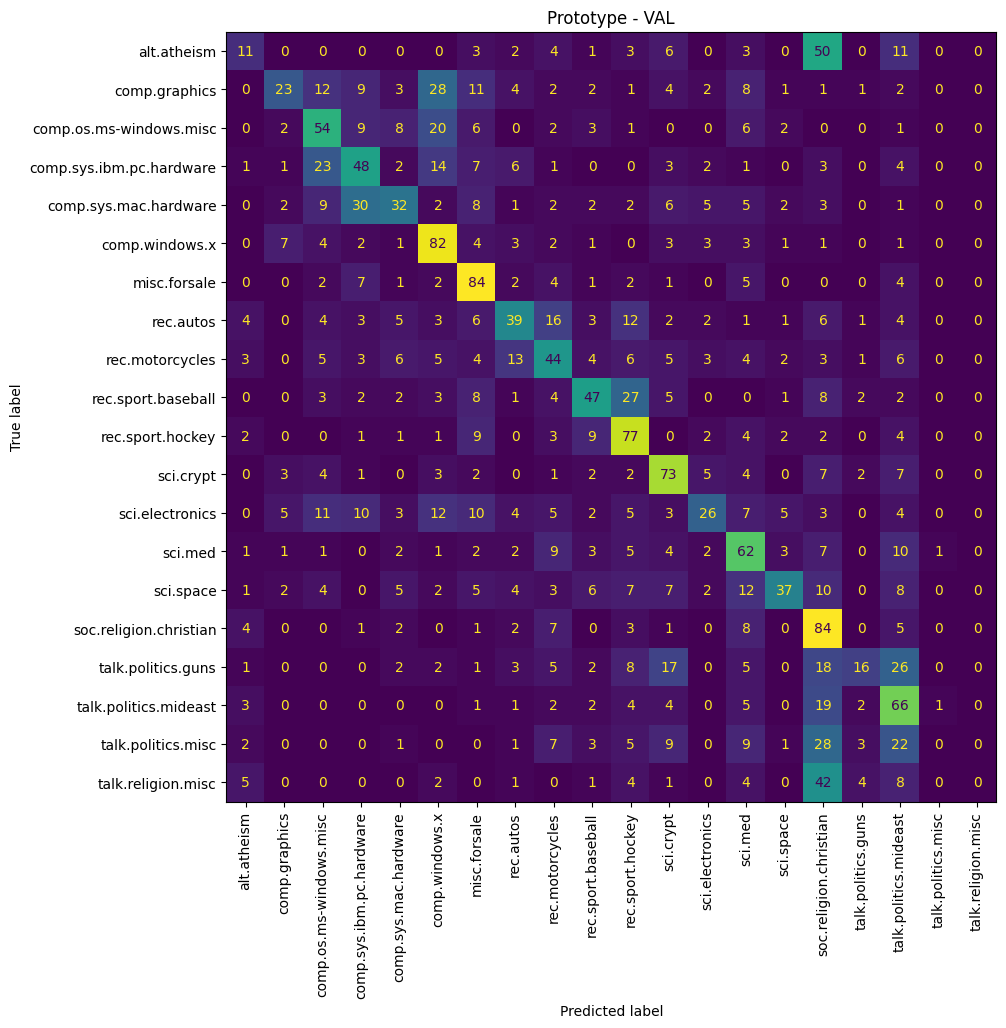

,true_id,true_label,pred_id,pred_label,text_preview
0,16,talk.politics.guns,4,comp.sys.mac.hardware,"I guess what I am really asking, like I did above, how does my government who is my servent, tell me the soveriegn what I can or cannot possess? It would s..."
1,0,alt.atheism,17,talk.politics.mideast,"Welcome. I am the official keeper of the list of nicknames that people are known by on alt.atheism (didn't know we had such a list, did you). Your have been..."
2,3,comp.sys.ibm.pc.hardware,6,misc.forsale,"Where did you get this driver. Please, please, please !!!! \tI've been waiting months for this."
3,5,comp.windows.x,1,comp.graphics,I *think* this is correct behavior. Remember the default colormapFocusPolicy is keyboard (meaning the cmap focus follows the keyboard focus). Since the dial...
4,16,talk.politics.guns,11,sci.crypt,"Let's see if I have this straight. A law is created that says ""you can not have a automatic weapon"" and therefore it's ok for the government to use any leve..."
5,7,rec.autos,2,comp.os.ms-windows.misc,"Place your hands flat on a table, and arrange the firing order from left to right."
6,13,sci.med,15,soc.religion.christian,"Surprise surprise, different people react differently to different things. One slightly off the subject case in point. My brother got stung by a bee. I know..."
7,19,talk.religion.misc,15,soc.religion.christian,"Jesus also recognized other holy days, like the Passover. Acts 15 says that no more should be layed on the Gentiles than that which is necessary. The sabbat..."
8,13,sci.med,9,rec.sport.baseball,">evidence of the 'yeast connection', I cannot guarantee their safety. >For their incompetence, ripping off their lips is justified as far as >I am concerned..."
9,1,comp.graphics,2,comp.os.ms-windows.misc,Hi Everyone-- It's spend-the-money-before-it-goes-away time here at U.Florida and we need to find some PC-based software that will do contour plotting with...



===== Prototype - TEST =====
Loss     : 2.4273
Accuracy : 0.3967
Macro F1 : 0.3510

                          precision    recall  f1-score   support

             alt.atheism     0.2033    0.0804    0.1152       311
           comp.graphics     0.3578    0.2161    0.2695       384
 comp.os.ms-windows.misc     0.3813    0.4195    0.3995       379
comp.sys.ibm.pc.hardware     0.4192    0.4301    0.4246       386
   comp.sys.mac.hardware     0.3610    0.2345    0.2843       371
          comp.windows.x     0.4329    0.6598    0.5228       391
            misc.forsale     0.4772    0.7670    0.5884       382
               rec.autos     0.4549    0.3493    0.3952       375
         rec.motorcycles     0.4037    0.4560    0.4282       386
      rec.sport.baseball     0.5132    0.4047    0.4526       383
        rec.sport.hockey     0.4747    0.7231    0.5732       390
               sci.crypt     0.4752    0.4789    0.4771       380
         sci.electronics     0.3116    0.1619    0.2131 

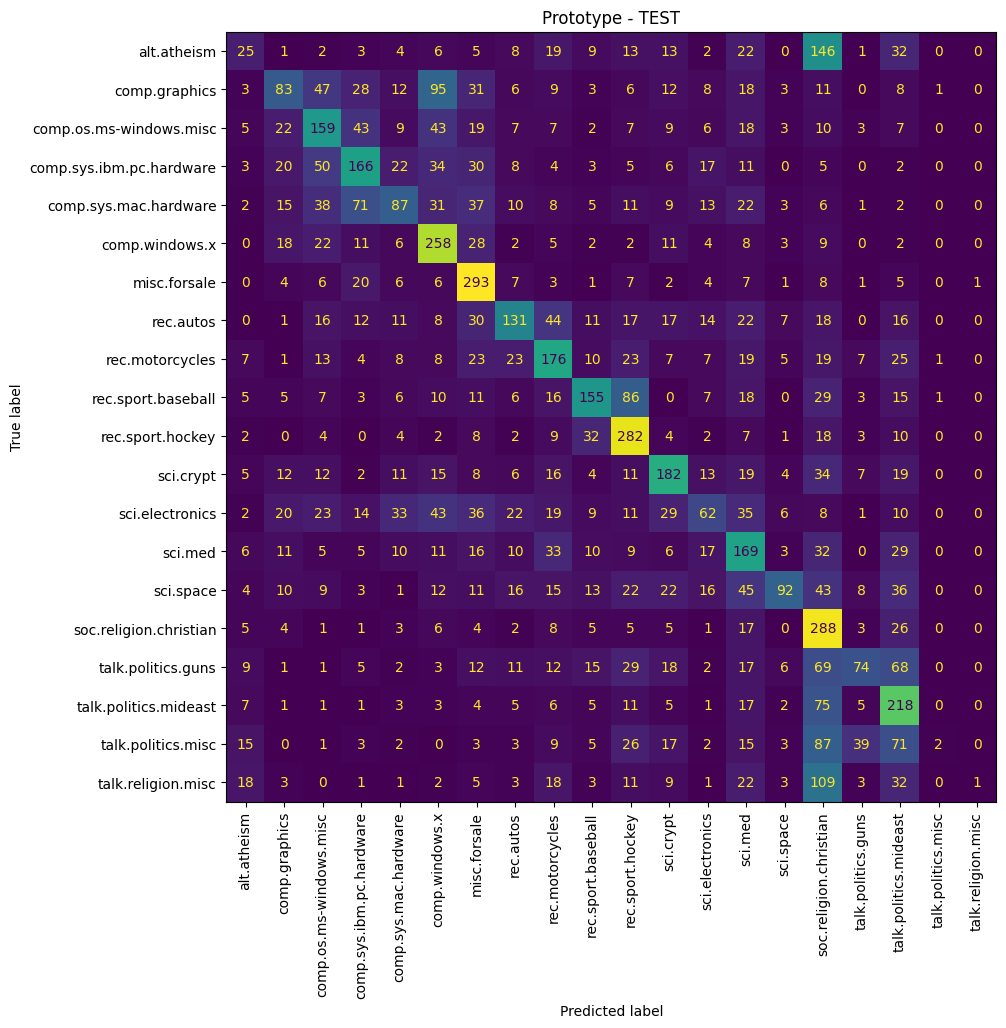

,true_id,true_label,pred_id,pred_label,text_preview
0,0,alt.atheism,11,sci.crypt,"In a word, yes."
1,19,talk.religion.misc,0,alt.atheism,I've just spent two solid months arguing that no such thing as an objective moral system exists.
2,15,soc.religion.christian,13,sci.med,"A friend of mine managed to get a copy of a computerised Greek and Hebrew Lexicon called ""The Word Perfect"" (That is not the word processing package WordPer..."
3,1,comp.graphics,2,comp.os.ms-windows.misc,": : well, i have lots of experience with scanning in images and altering : them. as for changing them back into negatives, is that really possible? : (stuf..."
4,8,rec.motorcycles,2,comp.os.ms-windows.misc,"Accusation? I thought it was a recommendation. (I mean, I did grow up there, I oughta know). Bring the truck and about 10 pounds of crawfish and we'll talk."
5,0,alt.atheism,15,soc.religion.christian,"Probably because it IS rape. So nothing. It may work for some, but not for others: it doesn't give any insight into an overall God or overall truth of a re..."
6,2,comp.os.ms-windows.misc,3,comp.sys.ibm.pc.hardware,"From article <C68uBG.K2w@world.std.com>, by cfw@world.std.com (Christopher F Wroten): Good question. Answer: The EISA bus does move 32 bits rather than ISA'..."
7,4,comp.sys.mac.hardware,3,comp.sys.ibm.pc.hardware,Iv'e got a problem printing with a StyleWriterII. I am printing from a IIvx with 20 megs ram. I am trying to print a Quark file that has 2 fonts a couple of...
8,1,comp.graphics,6,misc.forsale,"Hello, i'm interested in those devices too. Could also send me your suggestions. Thank in advance. Regards. --"
9,16,talk.politics.guns,6,misc.forsale,I just called Texas' legislative bill tracking service and found out that HB 1776 (Concealed Carry) is scheduled for a floor vote TODAY! Let those phone cal...


In [26]:
proto_val_result = evaluate_and_report(
    prototype_model,
    proto_val_loader,
    criterion,
    train_cfg.device,
    label_names,
    title="Prototype - VAL",
)
display(proto_val_result["errors_df"])

proto_test_result = evaluate_and_report(
    prototype_model,
    proto_test_loader,
    criterion,
    train_cfg.device,
    label_names,
    title="Prototype - TEST",
)
display(proto_test_result["errors_df"])


Block nay dinh nghia model BiLSTM voi `pack_padded_sequence` de LSTM khong xu ly pad token nhu token that.


In [27]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes, pad_idx, num_layers=1, bidirectional=True, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=lstm_dropout,
        )
        self.dropout = nn.Dropout(dropout)
        out_dim = hidden_size * 2 if bidirectional else hidden_size
        self.classifier = nn.Linear(out_dim, num_classes)
        self.bidirectional = bidirectional

    def forward(self, input_ids, lengths):
        emb = self.embedding(input_ids)
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        if self.bidirectional:
            final_hidden = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            final_hidden = h_n[-1]
        final_hidden = self.dropout(final_hidden)
        logits = self.classifier(final_hidden)
        return logits


Block nay tao DataLoader cho BiLSTM va cac train/eval loop rieng do BiLSTM can them `lengths`.


In [28]:
def train_one_epoch_lstm(model, loader, optimizer, criterion, device, grad_clip=None):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        lengths = batch["lengths"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()
        logits = model(input_ids, lengths)
        loss = criterion(logits, labels)
        loss.backward()
        if grad_clip is not None:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    return avg_loss, metrics


@torch.no_grad()
def eval_one_epoch_lstm(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_texts = []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        lengths = batch["lengths"].to(device)
        labels = batch["labels"].to(device)
        logits = model(input_ids, lengths)
        loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
        all_texts.extend(batch["raw_texts"])
    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    return avg_loss, metrics, np.array(all_labels), np.array(all_preds), all_texts


def fit_lstm(model, train_loader, val_loader, optimizer, criterion, device, epochs=8, grad_clip=1.0, patience=2, checkpoint_path=None):
    history = []
    best_val_f1 = -1.0
    best_state = None
    best_epoch = 0
    patience_counter = 0
    for epoch in range(1, epochs + 1):
        start = time.time()
        train_loss, train_metrics = train_one_epoch_lstm(model, train_loader, optimizer, criterion, device, grad_clip=grad_clip)
        val_loss, val_metrics, _, _, _ = eval_one_epoch_lstm(model, val_loader, criterion, device)
        epoch_time = time.time() - start
        lr_now = optimizer.param_groups[0]["lr"]
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_metrics["accuracy"],
            "val_acc": val_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "val_macro_f1": val_metrics["macro_f1"],
            "lr": lr_now,
            "epoch_time_sec": epoch_time,
        })
        print(f"[bilstm] Epoch {epoch:02d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} | train_acc={train_metrics['accuracy']:.4f} val_acc={val_metrics['accuracy']:.4f} | train_f1={train_metrics['macro_f1']:.4f} val_f1={val_metrics['macro_f1']:.4f} | lr={lr_now:.6f} | time={epoch_time:.1f}s")
        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if checkpoint_path is not None:
                torch.save(best_state, checkpoint_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"[bilstm] Early stopping at epoch {epoch:02d} | best_epoch={best_epoch:02d} | best_val_f1={best_val_f1:.4f}")
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"[bilstm] Best epoch: {best_epoch} | best_val_f1={best_val_f1:.4f}")
    return model, pd.DataFrame(history)


def evaluate_lstm(model, loader, criterion, device, label_names, title="BiLSTM"):
    loss, metrics, y_true, y_pred, raw_texts = eval_one_epoch_lstm(model, loader, criterion, device)
    print(f"\n===== {title} =====")
    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {metrics['accuracy']:.4f}")
    print(f"Macro F1 : {metrics['macro_f1']:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=label_names, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
    ax.set_title(title)
    plt.show()
    errors_df = collect_errors(raw_texts, y_true, y_pred, label_names, max_rows=15)
    return {
        "loss": loss,
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "y_true": y_true,
        "y_pred": y_pred,
        "errors_df": errors_df,
    }


bilstm_train_loader = DataLoader(train_ds, batch_size=train_cfg.bilstm_batch_size, shuffle=True, num_workers=train_cfg.num_workers, collate_fn=collate_batch)
bilstm_val_loader = DataLoader(val_ds, batch_size=train_cfg.bilstm_batch_size, shuffle=False, num_workers=train_cfg.num_workers, collate_fn=collate_batch)
bilstm_test_loader = DataLoader(test_ds, batch_size=train_cfg.bilstm_batch_size, shuffle=False, num_workers=train_cfg.num_workers, collate_fn=collate_batch)


Block nay train BiLSTM va luu lich su train/val de so sanh voi prototype va TF-IDF baseline.


In [29]:
bilstm_ckpt_path = processed_dir / "bilstm_best.pt"

bilstm_model = BiLSTMClassifier(
    vocab_size=len(itos),
    embed_dim=train_cfg.bilstm_embed_dim,
    hidden_size=train_cfg.bilstm_hidden_size,
    num_classes=num_classes,
    pad_idx=PAD_IDX,
    num_layers=train_cfg.bilstm_num_layers,
    bidirectional=train_cfg.bilstm_bidirectional,
    dropout=train_cfg.bilstm_dropout,
).to(train_cfg.device)

total_params, trainable_params = count_parameters(bilstm_model)
print("BiLSTM params:", total_params, "| trainable:", trainable_params)

criterion = nn.CrossEntropyLoss()
bilstm_optimizer = torch.optim.AdamW(
    bilstm_model.parameters(),
    lr=train_cfg.bilstm_lr,
    weight_decay=train_cfg.bilstm_weight_decay,
)

bilstm_model, bilstm_history = fit_lstm(
    model=bilstm_model,
    train_loader=bilstm_train_loader,
    val_loader=bilstm_val_loader,
    optimizer=bilstm_optimizer,
    criterion=criterion,
    device=train_cfg.device,
    epochs=train_cfg.bilstm_epochs,
    grad_clip=train_cfg.bilstm_grad_clip,
    patience=train_cfg.bilstm_patience,
    checkpoint_path=bilstm_ckpt_path,
)

display(bilstm_history)
print(f"Saved best BiLSTM checkpoint: {bilstm_ckpt_path}")


BiLSTM params: 7255724 | trainable: 7255724
[bilstm] Epoch 01 | train_loss=2.9219 val_loss=2.8287 | train_acc=0.1011 val_acc=0.1534 | train_f1=0.0905 val_f1=0.1286 | lr=0.001000 | time=6.4s
[bilstm] Epoch 02 | train_loss=2.5742 val_loss=2.5123 | train_acc=0.2212 val_acc=0.1920 | train_f1=0.2009 val_f1=0.1568 | lr=0.001000 | time=7.0s
[bilstm] Epoch 03 | train_loss=2.1569 val_loss=2.3008 | train_acc=0.3389 val_acc=0.2651 | train_f1=0.3202 val_f1=0.2452 | lr=0.001000 | time=7.4s
[bilstm] Epoch 04 | train_loss=1.7513 val_loss=2.1648 | train_acc=0.4621 val_acc=0.3010 | train_f1=0.4498 val_f1=0.2905 | lr=0.001000 | time=7.5s
[bilstm] Epoch 05 | train_loss=1.4009 val_loss=2.0107 | train_acc=0.5784 val_acc=0.3572 | train_f1=0.5669 val_f1=0.3422 | lr=0.001000 | time=8.0s
[bilstm] Epoch 06 | train_loss=1.0968 val_loss=1.9722 | train_acc=0.6709 val_acc=0.3890 | train_f1=0.6608 val_f1=0.3791 | lr=0.001000 | time=7.5s
[bilstm] Best epoch: 6 | best_val_f1=0.3791


,epoch,train_loss,val_loss,train_acc,val_acc,train_macro_f1,val_macro_f1,lr,epoch_time_sec
0,1,2.921935,2.828725,0.101124,0.153427,0.090465,0.128620,0.001,6.382036
1,2,2.574200,2.512285,0.221201,0.192011,0.200911,0.156841,0.001,6.986297
2,3,2.156861,2.300815,0.338895,0.265093,0.320204,0.245220,0.001,7.355855
3,4,1.751341,2.164792,0.462150,0.300953,0.449808,0.290488,0.001,7.501908
4,5,1.400914,2.010691,0.578368,0.357240,0.566932,0.342240,0.001,7.981145
5,6,1.096839,1.972155,0.670866,0.389015,0.660766,0.379054,0.001,7.503047


Saved best BiLSTM checkpoint: /home/godminhkhoa/Document/Deep-Learning-Assignment/Assignment1/data/classification/text/processed/bilstm_best.pt



===== BiLSTM - VAL =====
Loss     : 1.9722
Accuracy : 0.3890
Macro F1 : 0.3791

                          precision    recall  f1-score   support

             alt.atheism     0.3279    0.2128    0.2581        94
           comp.graphics     0.3942    0.3596    0.3761       114
 comp.os.ms-windows.misc     0.5432    0.3860    0.4513       114
comp.sys.ibm.pc.hardware     0.3212    0.5345    0.4013       116
   comp.sys.mac.hardware     0.3814    0.3304    0.3541       112
          comp.windows.x     0.5333    0.4068    0.4615       118
            misc.forsale     0.7525    0.6609    0.7037       115
               rec.autos     0.4762    0.2679    0.3429       112
         rec.motorcycles     0.3758    0.4786    0.4211       117
      rec.sport.baseball     0.4696    0.4696    0.4696       115
        rec.sport.hockey     0.5238    0.4701    0.4955       117
               sci.crypt     0.4815    0.4483    0.4643       116
         sci.electronics     0.2857    0.1913    0.2292     

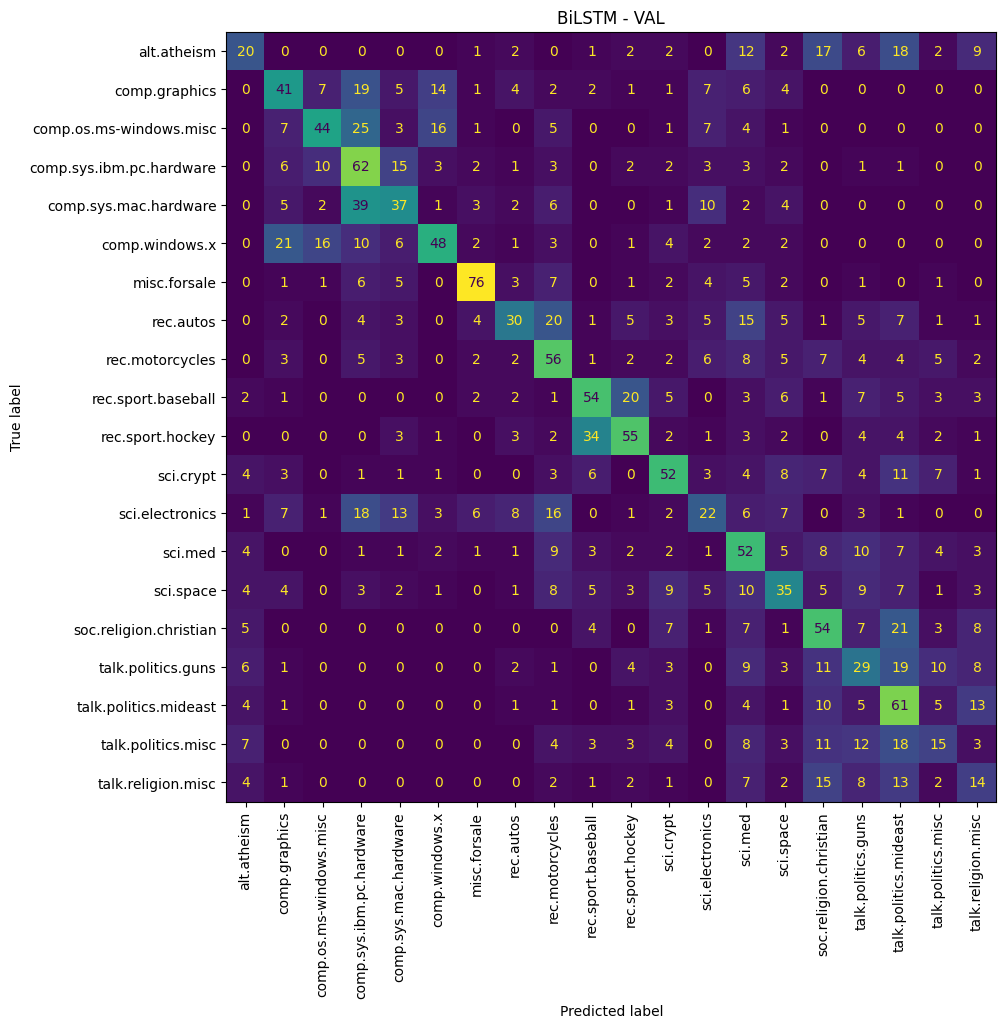

,true_id,true_label,pred_id,pred_label,text_preview
0,16,talk.politics.guns,17,talk.politics.mideast,"I guess what I am really asking, like I did above, how does my government who is my servent, tell me the soveriegn what I can or cannot possess? It would s..."
1,0,alt.atheism,17,talk.politics.mideast,"Welcome. I am the official keeper of the list of nicknames that people are known by on alt.atheism (didn't know we had such a list, did you). Your have been..."
2,2,comp.os.ms-windows.misc,12,sci.electronics,"All right. Not saying I know any more than the average salesguy, I'll give your question a shot. The key issue that I bought my BJ-200 on was ink drying sp..."
3,14,sci.space,13,sci.med,"Thanks for the information! I assume p is the semi-major axis and e the eccentricity. The peri- helion and aphelion are then given by p(1-e) and p(1+e), i...."
4,3,comp.sys.ibm.pc.hardware,12,sci.electronics,"Where did you get this driver. Please, please, please !!!! \tI've been waiting months for this."
5,9,rec.sport.baseball,13,sci.med,I've been saying that for at least 2 years now and even the A's conditioning guru told Jose he was carrying too much weight and losing some would help his b...
6,1,comp.graphics,3,comp.sys.ibm.pc.hardware,I'm interested in find out what is involved in processing pairs of stereo photographs. I have black-and-white photos and would like to obtain surface contou...
7,5,comp.windows.x,4,comp.sys.mac.hardware,I *think* this is correct behavior. Remember the default colormapFocusPolicy is keyboard (meaning the cmap focus follows the keyboard focus). Since the dial...
8,16,talk.politics.guns,19,talk.religion.misc,"Let's see if I have this straight. A law is created that says ""you can not have a automatic weapon"" and therefore it's ok for the government to use any leve..."
9,7,rec.autos,11,sci.crypt,"Place your hands flat on a table, and arrange the firing order from left to right."



===== BiLSTM - TEST =====
Loss     : 2.1448
Accuracy : 0.3377
Macro F1 : 0.3266

                          precision    recall  f1-score   support

             alt.atheism     0.1915    0.1447    0.1648       311
           comp.graphics     0.3089    0.3177    0.3132       384
 comp.os.ms-windows.misc     0.4981    0.3483    0.4099       379
comp.sys.ibm.pc.hardware     0.3161    0.4922    0.3850       386
   comp.sys.mac.hardware     0.2800    0.2453    0.2615       371
          comp.windows.x     0.5494    0.3274    0.4103       391
            misc.forsale     0.6561    0.7042    0.6793       382
               rec.autos     0.3640    0.2213    0.2753       375
         rec.motorcycles     0.3463    0.4145    0.3774       386
      rec.sport.baseball     0.4162    0.4021    0.4090       383
        rec.sport.hockey     0.5105    0.4359    0.4703       390
               sci.crypt     0.3372    0.3079    0.3219       380
         sci.electronics     0.1720    0.1123    0.1359    

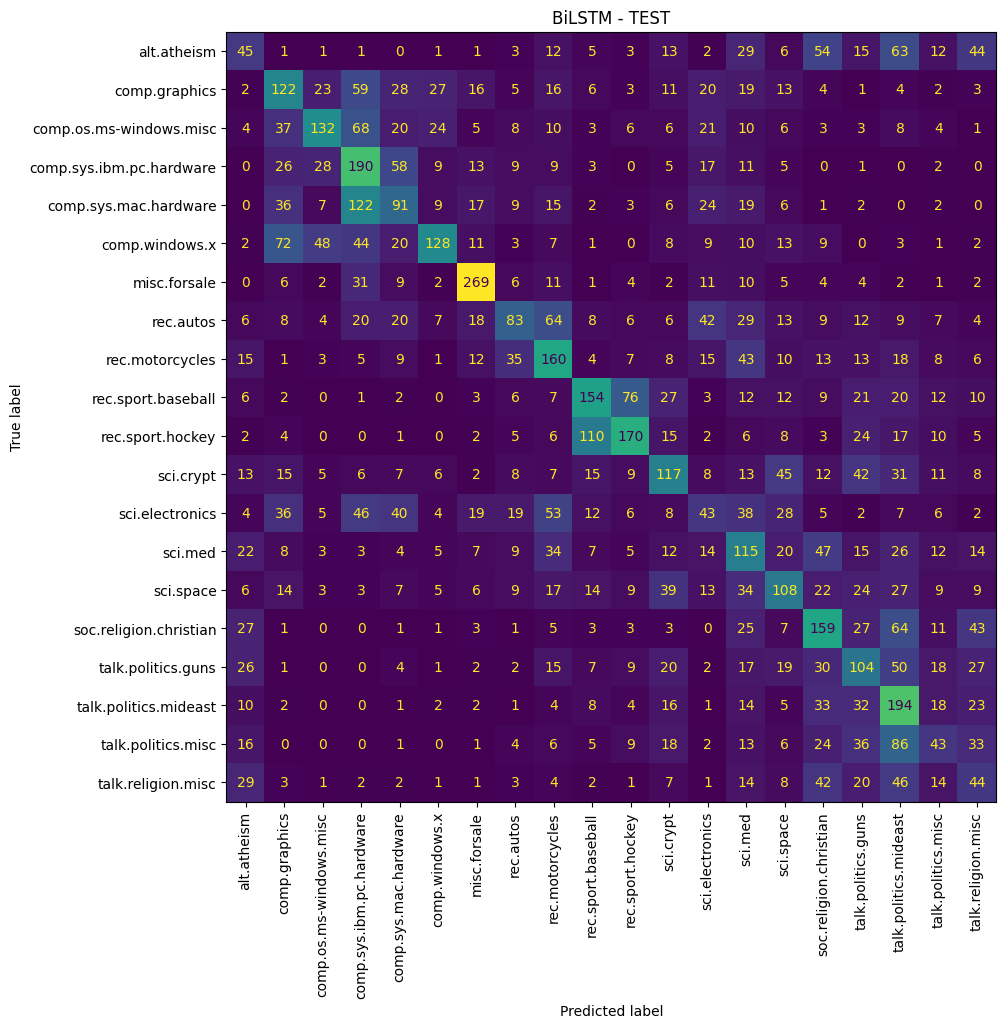

,true_id,true_label,pred_id,pred_label,text_preview
0,7,rec.autos,12,sci.electronics,I am a little confused on all of the models of the 88-89 bonnevilles. I have heard of the LE SE LSE SSE SSEI. Could someone tell me the differences are far ...
1,5,comp.windows.x,2,comp.os.ms-windows.misc,"I'm not familiar at all with the format of these ""X-Face:"" thingies, but after seeing them in some folks' headers, I've *got* to *see* them (and maybe make ..."
2,0,alt.atheism,13,sci.med,"In a word, yes."
3,17,talk.politics.mideast,16,talk.politics.guns,"They were attacking the Iraqis to drive them out of Kuwait, a country whose citizens have close blood and business ties to Saudi citizens. And me thinks if ..."
4,19,talk.religion.misc,14,sci.space,I've just spent two solid months arguing that no such thing as an objective moral system exists.
5,13,sci.med,16,talk.politics.guns,"Elisabeth, let's set the record straight for the nth time, I have not read ""The Yeast Connection"". So anything that I say is not due to brainwashing by this..."
6,15,soc.religion.christian,13,sci.med,"A friend of mine managed to get a copy of a computerised Greek and Hebrew Lexicon called ""The Word Perfect"" (That is not the word processing package WordPer..."
7,5,comp.windows.x,1,comp.graphics,"Hi, We have a requirement for dynamically closing and opening different display servers within an X application in a manner such that at any time there is ..."
8,1,comp.graphics,4,comp.sys.mac.hardware,": : well, i have lots of experience with scanning in images and altering : them. as for changing them back into negatives, is that really possible? : (stuf..."
9,8,rec.motorcycles,17,talk.politics.mideast,"Accusation? I thought it was a recommendation. (I mean, I did grow up there, I oughta know). Bring the truck and about 10 pounds of crawfish and we'll talk."


In [30]:
bilstm_val_result = evaluate_lstm(
    bilstm_model,
    bilstm_val_loader,
    criterion,
    train_cfg.device,
    label_names,
    title="BiLSTM - VAL",
)
display(bilstm_val_result["errors_df"])

bilstm_test_result = evaluate_lstm(
    bilstm_model,
    bilstm_test_loader,
    criterion,
    train_cfg.device,
    label_names,
    title="BiLSTM - TEST",
)
display(bilstm_test_result["errors_df"])


Block nay tong hop ket qua de so sanh 3 moc: TF-IDF baseline, neural prototype va BiLSTM.


In [31]:
results_df = pd.DataFrame([
    {
        "model": "TF-IDF + LogisticRegression",
        "val_acc": accuracy_score(y_val, val_pred_tfidf),
        "val_macro_f1": f1_score(y_val, val_pred_tfidf, average="macro"),
        "test_acc": accuracy_score(y_test, test_pred_tfidf),
        "test_macro_f1": f1_score(y_test, test_pred_tfidf, average="macro"),
    },
    {
        "model": "Embedding + MeanPooling",
        "val_acc": proto_val_result["accuracy"],
        "val_macro_f1": proto_val_result["macro_f1"],
        "test_acc": proto_test_result["accuracy"],
        "test_macro_f1": proto_test_result["macro_f1"],
    },
    {
        "model": "BiLSTM",
        "val_acc": bilstm_val_result["accuracy"],
        "val_macro_f1": bilstm_val_result["macro_f1"],
        "test_acc": bilstm_test_result["accuracy"],
        "test_macro_f1": bilstm_test_result["macro_f1"],
    },
])

display(results_df.sort_values("val_macro_f1", ascending=False))


,model,val_acc,val_macro_f1,test_acc,test_macro_f1
0,TF-IDF + LogisticRegression,0.750340,0.740398,0.685527,0.670120
2,BiLSTM,0.389015,0.379054,0.337707,0.326603
1,Embedding + MeanPooling,0.410803,0.364556,0.396747,0.351003


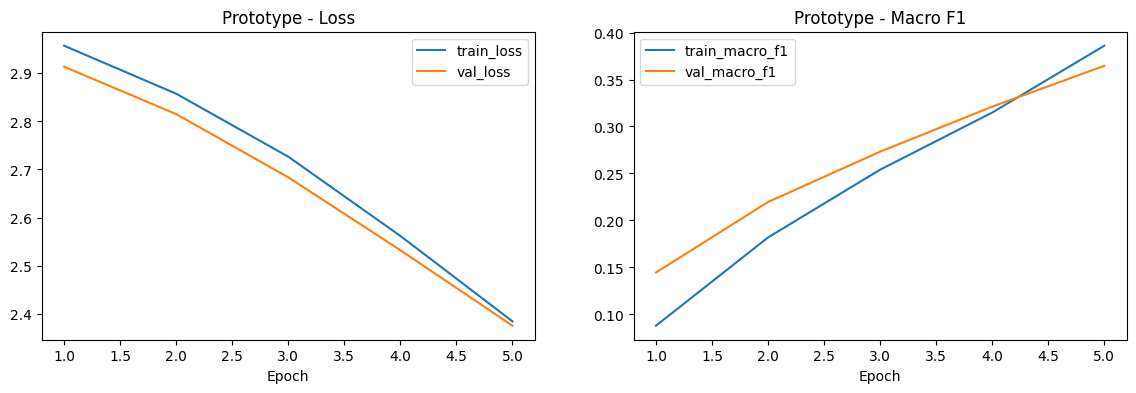

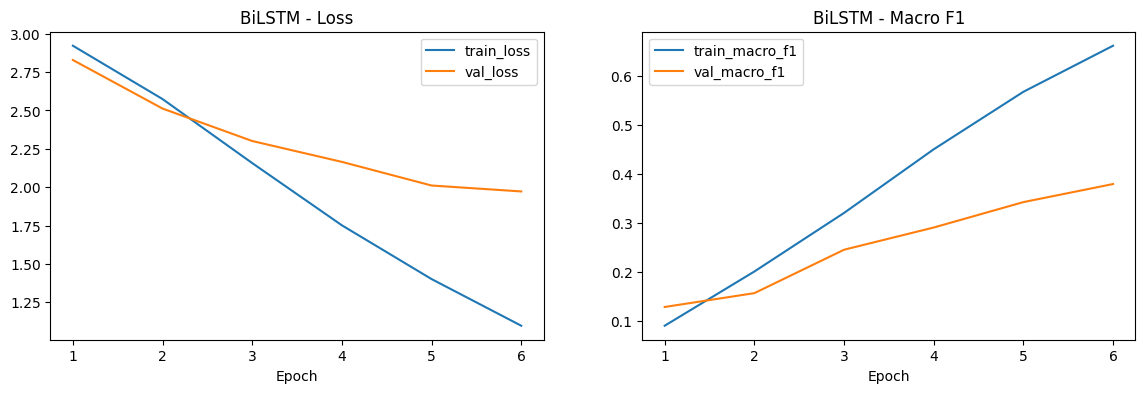

In [32]:
def plot_history(history_df, title="history"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_macro_f1"], label="train_macro_f1")
    axes[1].plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f1")
    axes[1].set_title(f"{title} - Macro F1")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.show()


plot_history(proto_history, title="Prototype")
plot_history(bilstm_history, title="BiLSTM")


## 5. DistilBERT

Phan nay gom 2 muc: frozen DistilBERT va full fine-tuning DistilBERT.


### Ý nghĩa block code

Block này khai báo cấu hình riêng cho nhánh DistilBERT, bao gồm tên mô hình, độ dài chuỗi tối đa, batch size, số epoch, learning rate và thư mục lưu checkpoint.


In [33]:
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

cfg = train_cfg
cfg.bert_model_name = "distilbert-base-uncased"
cfg.bert_max_length = 384
cfg.bert_batch_size = 16

cfg.bert_frozen_dropout = 0.2
cfg.bert_frozen_lr = 1e-3
cfg.bert_frozen_weight_decay = 1e-4
cfg.bert_frozen_epochs = 4

cfg.bert_ft_dropout = 0.2
cfg.bert_ft_lr = 2e-5
cfg.bert_ft_weight_decay = 1e-2
cfg.bert_ft_epochs = 4
cfg.bert_warmup_ratio = 0.1
cfg.bert_grad_clip = 1.0
cfg.bert_patience = 2

cfg.bert_ckpt_dir = str(processed_dir / "bert_checkpoints")
os.makedirs(cfg.bert_ckpt_dir, exist_ok=True)

print("BERT config ready.")
print("Model name   :", cfg.bert_model_name)
print("Max length   :", cfg.bert_max_length)
print("Batch size   :", cfg.bert_batch_size)
print("Checkpoint dir:", cfg.bert_ckpt_dir)


BERT config ready.
Model name   : distilbert-base-uncased
Max length   : 384
Batch size   : 16
Checkpoint dir: /home/godminhkhoa/Document/Deep-Learning-Assignment/Assignment1/data/classification/text/processed/bert_checkpoints


### Ý nghĩa block code

Block này tải tokenizer của DistilBERT, thống kê độ dài token trên tập train và validation, rồi in thử một vài ví dụ token hóa để kiểm tra xem `bert_max_length` hiện tại có hợp lý hay không.


In [34]:
bert_tokenizer = AutoTokenizer.from_pretrained(cfg.bert_model_name)
print("Tokenizer loaded:", cfg.bert_model_name)
print("Tokenizer vocab size:", bert_tokenizer.vocab_size)
print("Tokenizer model max length:", bert_tokenizer.model_max_length)


def bert_token_length_stats(texts, tokenizer, max_length):
    lengths = []
    truncated = 0
    for text in texts:
        ids = tokenizer(text, truncation=False, padding=False)["input_ids"]
        lengths.append(len(ids))
        if len(ids) > max_length:
            truncated += 1
    lengths = np.array(lengths)
    return {
        "num_samples": int(len(lengths)),
        "mean_len": float(lengths.mean()),
        "median_len": float(np.median(lengths)),
        "p90_len": float(np.percentile(lengths, 90)),
        "p95_len": float(np.percentile(lengths, 95)),
        "p99_len": float(np.percentile(lengths, 99)),
        "max_len": int(lengths.max()),
        "truncated_samples": int(truncated),
        "truncation_rate": float(truncated / len(lengths)),
        "max_length_setting": int(max_length),
    }


train_bert_stats = bert_token_length_stats(train_texts, bert_tokenizer, cfg.bert_max_length)
val_bert_stats = bert_token_length_stats(val_texts, bert_tokenizer, cfg.bert_max_length)

print("Train BERT token stats:", train_bert_stats)
print("Val   BERT token stats:", val_bert_stats)

for i in range(2):
    text = train_texts[i]
    enc = bert_tokenizer(text, truncation=True, max_length=cfg.bert_max_length)
    print("=" * 100)
    print("Label:", label_names[y_train[i]])
    print("Raw text preview:", text[:250])
    print("Tokenized length:", len(enc["input_ids"]))
    print("First 30 token ids:", enc["input_ids"][:30])
    print("First 30 tokens:", bert_tokenizer.convert_ids_to_tokens(enc["input_ids"][:30]))


Token indices sequence length is longer than the specified maximum sequence length for this model (589 > 512). Running this sequence through the model will result in indexing errors


Tokenizer loaded: distilbert-base-uncased
Tokenizer vocab size: 30522
Tokenizer model max length: 512
Train BERT token stats: {'num_samples': 8811, 'mean_len': 375.01691067983205, 'median_len': 128.0, 'p90_len': 488.0, 'p95_len': 838.0, 'p99_len': 3469.5999999999476, 'max_len': 52886, 'truncated_samples': 1214, 'truncation_rate': 0.13778231755759845, 'max_length_setting': 384}
Val   BERT token stats: {'num_samples': 2203, 'mean_len': 316.26554698138904, 'median_len': 132.0, 'p90_len': 478.0, 'p95_len': 797.6000000000004, 'p99_len': 2812.600000000002, 'max_len': 50792, 'truncated_samples': 319, 'truncation_rate': 0.14480254198819792, 'max_length_setting': 384}
Label: comp.sys.ibm.pc.hardware
Raw text preview: I think it is an ESDI controller if you need the doco i can help you.

Stefan
Tokenized length: 22
First 30 token ids: [101, 1045, 2228, 2009, 2003, 2019, 9686, 4305, 11486, 2065, 2017, 2342, 1996, 9986, 2080, 1045, 2064, 2393, 2017, 1012, 8852, 102]
First 30 tokens: ['[CLS]', 'i',

### Ý nghĩa block code

Block này tạo `Dataset` và `collator` cho DistilBERT. Văn bản sẽ được tokenize theo từng batch để padding động, cắt chuỗi theo `max_length` và giữ lại raw text để phục vụ phân tích lỗi.


In [35]:
class BertTextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            "text": self.texts[idx],
            "label": int(self.labels[idx]),
        }


class BertCollator:
    def __init__(self, tokenizer, max_length):
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __call__(self, batch):
        texts = [item["text"] for item in batch]
        labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)
        encodings = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )
        encodings["labels"] = labels
        encodings["raw_texts"] = texts
        return encodings


bert_train_ds = BertTextDataset(train_texts, y_train)
bert_val_ds = BertTextDataset(val_texts, y_val)
bert_test_ds = BertTextDataset(test_texts, y_test)

bert_collator = BertCollator(tokenizer=bert_tokenizer, max_length=cfg.bert_max_length)

bert_train_loader = DataLoader(bert_train_ds, batch_size=cfg.bert_batch_size, shuffle=True, num_workers=cfg.num_workers, collate_fn=bert_collator)
bert_val_loader = DataLoader(bert_val_ds, batch_size=cfg.bert_batch_size, shuffle=False, num_workers=cfg.num_workers, collate_fn=bert_collator)
bert_test_loader = DataLoader(bert_test_ds, batch_size=cfg.bert_batch_size, shuffle=False, num_workers=cfg.num_workers, collate_fn=bert_collator)

sample_batch = next(iter(bert_train_loader))
print("input_ids shape     :", sample_batch["input_ids"].shape)
print("attention_mask shape:", sample_batch["attention_mask"].shape)
print("labels shape        :", sample_batch["labels"].shape)


input_ids shape     : torch.Size([16, 384])
attention_mask shape: torch.Size([16, 384])
labels shape        : torch.Size([16])


### Ý nghĩa block code

Block này định nghĩa mô hình phân loại dùng DistilBERT. Cùng một class được dùng cho hai chế độ: đóng băng backbone để chạy nhanh hoặc fine-tune toàn bộ mô hình.


In [36]:
class DistilBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.2, freeze_backbone=False):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)
        self.freeze_backbone = freeze_backbone

        if self.freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        if self.freeze_backbone:
            self.backbone.eval()
            with torch.no_grad():
                outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        else:
            outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)

        cls_rep = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(self.dropout(cls_rep))
        return logits


### Ý nghĩa block code

Block này cài đặt train loop và evaluation loop riêng cho DistilBERT, có hỗ trợ scheduler, early stopping, lưu checkpoint tốt nhất, tính metrics và hiển thị confusion matrix.


In [37]:
def train_one_epoch_bert(model, loader, optimizer, criterion, device, scheduler=None, grad_clip=None):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)
        loss.backward()

        if grad_clip is not None:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    return avg_loss, metrics


@torch.no_grad()
def eval_one_epoch_bert(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_texts = []
    all_confidences = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        confs, preds = torch.max(probs, dim=1)

        total_loss += loss.item() * labels.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
        all_confidences.extend(confs.detach().cpu().numpy())
        all_texts.extend(batch["raw_texts"])

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    return avg_loss, metrics, np.array(all_labels), np.array(all_preds), np.array(all_confidences), all_texts


def fit_bert(model, train_loader, val_loader, optimizer, criterion, device, epochs, patience=2, scheduler=None, grad_clip=None, model_name="bert", save_path=None):
    history = []
    best_val_f1 = -1.0
    best_state = None
    best_epoch = -1
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        start = time.time()
        train_loss, train_metrics = train_one_epoch_bert(model, train_loader, optimizer, criterion, device, scheduler=scheduler, grad_clip=grad_clip)
        val_loss, val_metrics, _, _, _, _ = eval_one_epoch_bert(model, val_loader, criterion, device)
        epoch_time = time.time() - start
        lr_now = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_metrics["accuracy"],
            "val_acc": val_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "val_macro_f1": val_metrics["macro_f1"],
            "lr": lr_now,
            "epoch_time_sec": epoch_time,
        }
        history.append(row)

        print(f"[{model_name}] Epoch {epoch:02d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} | train_acc={train_metrics['accuracy']:.4f} val_acc={val_metrics['accuracy']:.4f} | train_f1={train_metrics['macro_f1']:.4f} val_f1={val_metrics['macro_f1']:.4f} | lr={lr_now:.6f} | time={epoch_time:.1f}s")

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if save_path is not None:
                torch.save(best_state, save_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"[{model_name}] Early stopping triggered at epoch {epoch}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    print(f"[{model_name}] Best epoch = {best_epoch} | Best val_macro_f1 = {best_val_f1:.4f}")
    return model, history_df


def evaluate_bert(model, loader, criterion, device, label_names, title="DistilBERT"):
    loss, metrics, y_true, y_pred, confidences, raw_texts = eval_one_epoch_bert(model, loader, criterion, device)
    print(f"\n===== {title} =====")
    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {metrics['accuracy']:.4f}")
    print(f"Macro F1 : {metrics['macro_f1']:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=label_names, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
    ax.set_title(title)
    plt.show()

    error_rows = []
    for text, yt, yp, conf in zip(raw_texts, y_true, y_pred, confidences):
        if yt != yp:
            error_rows.append({
                "true_id": int(yt),
                "true_label": label_names[yt],
                "pred_id": int(yp),
                "pred_label": label_names[yp],
                "confidence": float(conf),
                "text_preview": text[:300].replace("\n", " "),
            })
    errors_df = pd.DataFrame(error_rows[:15])

    return {
        "loss": loss,
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "y_true": y_true,
        "y_pred": y_pred,
        "errors_df": errors_df,
    }


### Ý nghĩa block code

Block này huấn luyện bản DistilBERT frozen, tức là chỉ học classifier head trong khi giữ nguyên pretrained backbone. Mục tiêu là lấy một mốc transformer nhẹ để so sánh trước khi fine-tune toàn bộ mô hình.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Frozen DistilBERT params: 66378260 | trainable: 15380
[distilbert_frozen] Epoch 01 | train_loss=1.8171 val_loss=1.3301 | train_acc=0.5116 val_acc=0.6196 | train_f1=0.4879 val_f1=0.5949 | lr=0.001000 | time=46.3s
[distilbert_frozen] Epoch 02 | train_loss=1.2459 val_loss=1.1559 | train_acc=0.6277 val_acc=0.6459 | train_f1=0.6097 val_f1=0.6262 | lr=0.001000 | time=45.9s
[distilbert_frozen] Epoch 03 | train_loss=1.1221 val_loss=1.0989 | train_acc=0.6529 val_acc=0.6500 | train_f1=0.6385 val_f1=0.6336 | lr=0.001000 | time=46.2s
[distilbert_frozen] Epoch 04 | train_loss=1.0641 val_loss=1.0570 | train_acc=0.6694 val_acc=0.6655 | train_f1=0.6557 val_f1=0.6455 | lr=0.001000 | time=46.0s
[distilbert_frozen] Best epoch = 4 | Best val_macro_f1 = 0.6455


,epoch,train_loss,val_loss,train_acc,val_acc,train_macro_f1,val_macro_f1,lr,epoch_time_sec
0,1,1.817143,1.330077,0.511633,0.619610,0.487922,0.594942,0.001,46.262465
1,2,1.245864,1.155935,0.627738,0.645937,0.609657,0.626196,0.001,45.926177
2,3,1.122056,1.098938,0.652934,0.650023,0.638494,0.633551,0.001,46.171961
3,4,1.064078,1.056991,0.669391,0.665456,0.655657,0.645520,0.001,45.990533


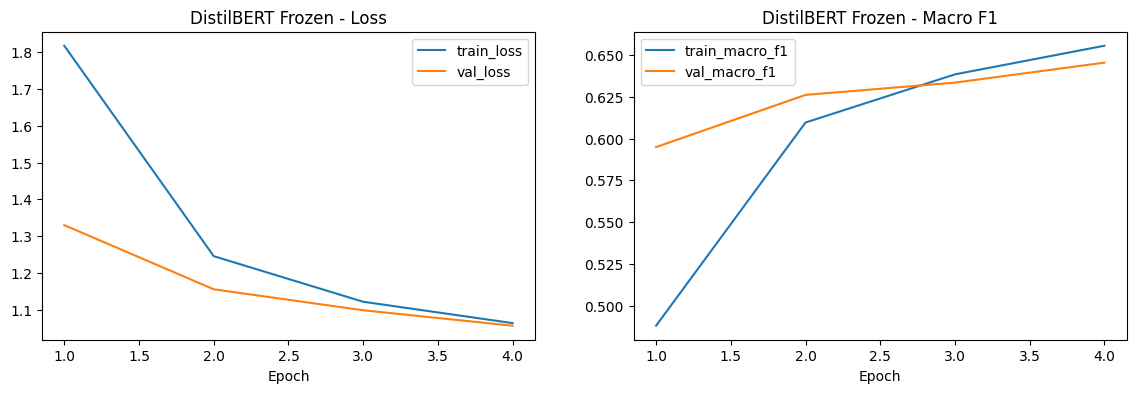

In [38]:
frozen_bert = DistilBERTClassifier(
    model_name=cfg.bert_model_name,
    num_classes=num_classes,
    dropout=cfg.bert_frozen_dropout,
    freeze_backbone=True,
).to(cfg.device)

total_params, trainable_params = count_parameters(frozen_bert)
print("Frozen DistilBERT params:", total_params, "| trainable:", trainable_params)

criterion_bert = nn.CrossEntropyLoss()

frozen_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, frozen_bert.parameters()),
    lr=cfg.bert_frozen_lr,
    weight_decay=cfg.bert_frozen_weight_decay,
)

frozen_ckpt_path = os.path.join(cfg.bert_ckpt_dir, "distilbert_frozen_best.pt")

frozen_bert, frozen_history = fit_bert(
    model=frozen_bert,
    train_loader=bert_train_loader,
    val_loader=bert_val_loader,
    optimizer=frozen_optimizer,
    criterion=criterion_bert,
    device=cfg.device,
    epochs=cfg.bert_frozen_epochs,
    patience=cfg.bert_patience,
    scheduler=None,
    grad_clip=cfg.bert_grad_clip,
    model_name="distilbert_frozen",
    save_path=frozen_ckpt_path,
)

display(frozen_history)
plot_history(frozen_history, title="DistilBERT Frozen")


### Ý nghĩa block code

Block này đánh giá DistilBERT frozen trên validation và test, sau đó trích các mẫu dự đoán sai đầu tiên để phục vụ phân tích lỗi.



===== DistilBERT Frozen - VAL =====
Loss     : 1.0570
Accuracy : 0.6655
Macro F1 : 0.6455

                          precision    recall  f1-score   support

             alt.atheism     0.4274    0.5319    0.4739        94
           comp.graphics     0.7903    0.4298    0.5568       114
 comp.os.ms-windows.misc     0.3687    0.6404    0.4679       114
comp.sys.ibm.pc.hardware     0.5408    0.4569    0.4953       116
   comp.sys.mac.hardware     0.6078    0.5536    0.5794       112
          comp.windows.x     0.7010    0.5763    0.6326       118
            misc.forsale     0.7107    0.7478    0.7288       115
               rec.autos     0.6748    0.7411    0.7064       112
         rec.motorcycles     0.7087    0.6239    0.6636       117
      rec.sport.baseball     0.8103    0.8174    0.8139       115
        rec.sport.hockey     0.8919    0.8462    0.8684       117
               sci.crypt     0.7087    0.7759    0.7407       116
         sci.electronics     0.6495    0.5478    

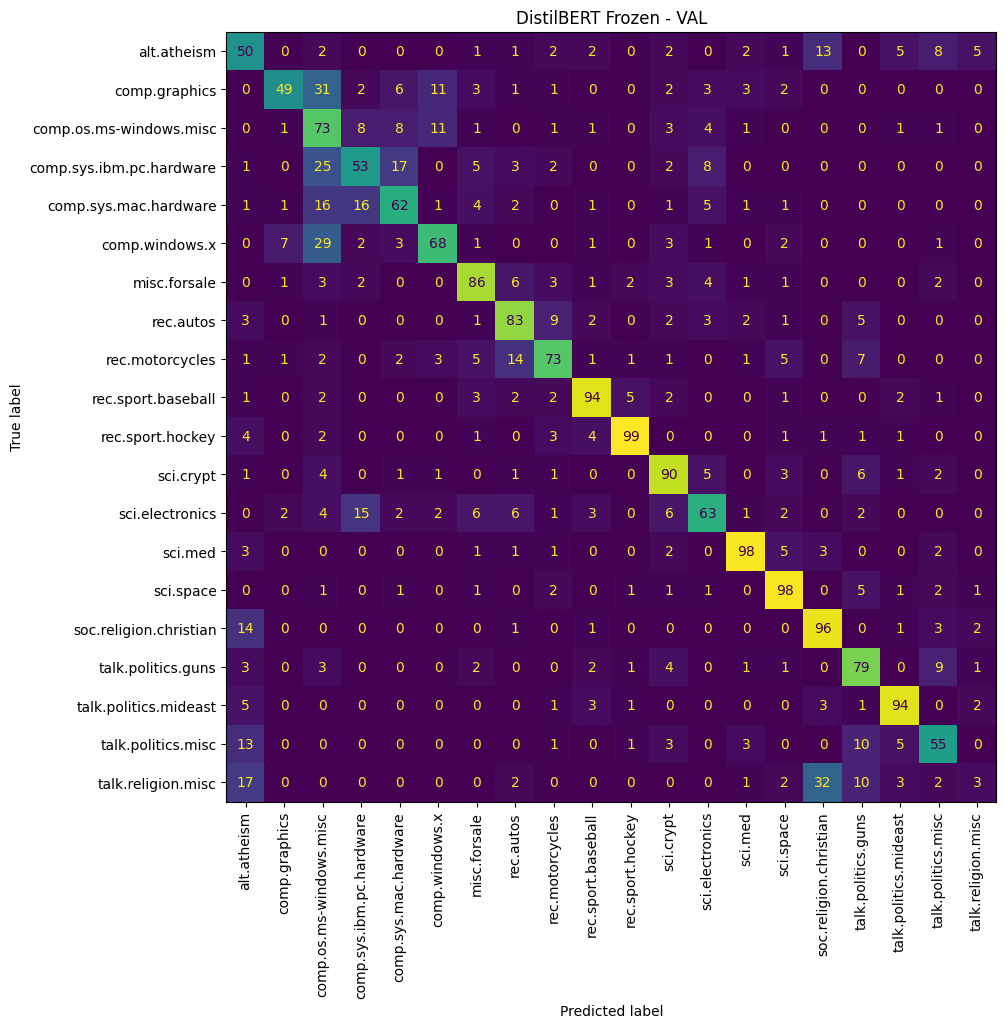

,true_id,true_label,pred_id,pred_label,confidence,text_preview
0,0,alt.atheism,8,rec.motorcycles,0.214604,"Welcome. I am the official keeper of the list of nicknames that people are known by on alt.atheism (didn't know we had such a list, did you). Your have been..."
1,2,comp.os.ms-windows.misc,4,comp.sys.mac.hardware,0.357549,"All right. Not saying I know any more than the average salesguy, I'll give your question a shot. The key issue that I bought my BJ-200 on was ink drying sp..."
2,3,comp.sys.ibm.pc.hardware,7,rec.autos,0.725603,"Where did you get this driver. Please, please, please !!!! \tI've been waiting months for this."
3,16,talk.politics.guns,14,sci.space,0.389297,"Let's see if I have this straight. A law is created that says ""you can not have a automatic weapon"" and therefore it's ok for the government to use any leve..."
4,7,rec.autos,16,talk.politics.guns,0.483932,"Place your hands flat on a table, and arrange the firing order from left to right."
5,19,talk.religion.misc,15,soc.religion.christian,0.828961,"Jesus also recognized other holy days, like the Passover. Acts 15 says that no more should be layed on the Gentiles than that which is necessary. The sabbat..."
6,13,sci.med,0,alt.atheism,0.200608,">evidence of the 'yeast connection', I cannot guarantee their safety. >For their incompetence, ripping off their lips is justified as far as >I am concerned..."
7,1,comp.graphics,14,sci.space,0.248454,Hi Everyone-- It's spend-the-money-before-it-goes-away time here at U.Florida and we need to find some PC-based software that will do contour plotting with...
8,12,sci.electronics,14,sci.space,0.153479,"{Kris Gleason} said ""Re: what to do with old 2"" to <All> on 04-15-93 11:02 KG> Yeah... keychains. I have seen 64K simms with a silver KG> keyring attached, ..."
9,18,talk.politics.misc,0,alt.atheism,0.328293,"I get it. One organization wants to abolish age of consent laws, whereas in contrast the other wants to abolish age of consent laws. This makes it respectab..."



===== DistilBERT Frozen - TEST =====
Loss     : 1.1658
Accuracy : 0.6388
Macro F1 : 0.6194

                          precision    recall  f1-score   support

             alt.atheism     0.3664    0.4277    0.3947       311
           comp.graphics     0.7304    0.4375    0.5472       384
 comp.os.ms-windows.misc     0.3718    0.6544    0.4742       379
comp.sys.ibm.pc.hardware     0.5747    0.4585    0.5101       386
   comp.sys.mac.hardware     0.5709    0.4340    0.4931       371
          comp.windows.x     0.6667    0.4910    0.5655       391
            misc.forsale     0.6820    0.8141    0.7422       382
               rec.autos     0.6995    0.7760    0.7358       375
         rec.motorcycles     0.7246    0.6477    0.6840       386
      rec.sport.baseball     0.7764    0.8433    0.8085       383
        rec.sport.hockey     0.8886    0.8590    0.8735       390
               sci.crypt     0.6247    0.6921    0.6567       380
         sci.electronics     0.5753    0.5483   

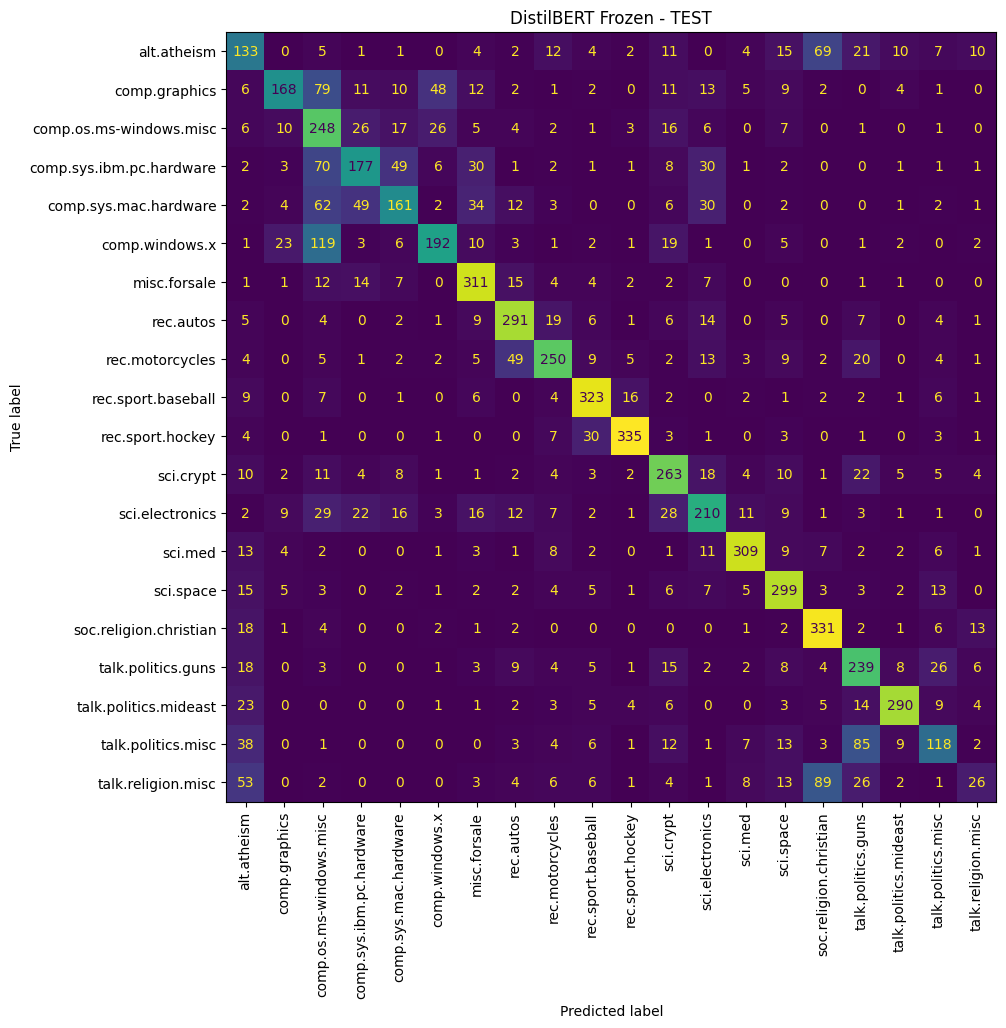

,true_id,true_label,pred_id,pred_label,confidence,text_preview
0,5,comp.windows.x,2,comp.os.ms-windows.misc,0.485972,"I'm not familiar at all with the format of these ""X-Face:"" thingies, but after seeing them in some folks' headers, I've *got* to *see* them (and maybe make ..."
1,0,alt.atheism,9,rec.sport.baseball,0.149702,"In a word, yes."
2,19,talk.religion.misc,0,alt.atheism,0.364705,I've just spent two solid months arguing that no such thing as an objective moral system exists.
3,15,soc.religion.christian,19,talk.religion.misc,0.666318,"Dishonest money dwindles away, but he who gathers money little by little makes it grow. Proverbs 13:11"
4,15,soc.religion.christian,2,comp.os.ms-windows.misc,0.299351,"A friend of mine managed to get a copy of a computerised Greek and Hebrew Lexicon called ""The Word Perfect"" (That is not the word processing package WordPer..."
5,8,rec.motorcycles,7,rec.autos,0.388173,"Accusation? I thought it was a recommendation. (I mean, I did grow up there, I oughta know). Bring the truck and about 10 pounds of crawfish and we'll talk."
6,2,comp.os.ms-windows.misc,3,comp.sys.ibm.pc.hardware,0.452885,"From article <C68uBG.K2w@world.std.com>, by cfw@world.std.com (Christopher F Wroten): Good question. Answer: The EISA bus does move 32 bits rather than ISA'..."
7,4,comp.sys.mac.hardware,2,comp.os.ms-windows.misc,0.395906,Iv'e got a problem printing with a StyleWriterII. I am printing from a IIvx with 20 megs ram. I am trying to print a Quark file that has 2 fonts a couple of...
8,1,comp.graphics,6,misc.forsale,0.195830,"Hello, i'm interested in those devices too. Could also send me your suggestions. Thank in advance. Regards. --"
9,3,comp.sys.ibm.pc.hardware,17,talk.politics.mideast,0.147603,"I don't know about Canada, but I have heard from people doing translation work in Papua New Quinea, that they like them and have had good response on servic..."


Frozen checkpoint saved to: /home/godminhkhoa/Document/Deep-Learning-Assignment/Assignment1/data/classification/text/processed/bert_checkpoints/distilbert_frozen_best.pt


In [39]:
frozen_val_result = evaluate_bert(
    model=frozen_bert,
    loader=bert_val_loader,
    criterion=criterion_bert,
    device=cfg.device,
    label_names=label_names,
    title="DistilBERT Frozen - VAL",
)
display(frozen_val_result["errors_df"])

frozen_test_result = evaluate_bert(
    model=frozen_bert,
    loader=bert_test_loader,
    criterion=criterion_bert,
    device=cfg.device,
    label_names=label_names,
    title="DistilBERT Frozen - TEST",
)
display(frozen_test_result["errors_df"])

print("Frozen checkpoint saved to:", frozen_ckpt_path)


### Ý nghĩa block code

Block này huấn luyện DistilBERT theo chế độ fine-tune toàn phần, kết hợp learning rate nhỏ, weight decay và warmup scheduler để kiểm tra xem mô hình có vượt được bản frozen hay không.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fine-tune DistilBERT params: 66378260 | trainable: 66378260
[distilbert_finetune] Epoch 01 | train_loss=1.7085 val_loss=0.8896 | train_acc=0.4989 val_acc=0.7249 | train_f1=0.4936 val_f1=0.7000 | lr=0.000017 | time=128.0s
[distilbert_finetune] Epoch 02 | train_loss=0.7627 val_loss=0.8121 | train_acc=0.7682 val_acc=0.7449 | train_f1=0.7510 val_f1=0.7208 | lr=0.000011 | time=128.3s
[distilbert_finetune] Epoch 03 | train_loss=0.5126 val_loss=0.7857 | train_acc=0.8486 val_acc=0.7626 | train_f1=0.8369 val_f1=0.7518 | lr=0.000006 | time=127.9s
[distilbert_finetune] Epoch 04 | train_loss=0.3794 val_loss=0.7787 | train_acc=0.8895 val_acc=0.7662 | train_f1=0.8799 val_f1=0.7525 | lr=0.000000 | time=128.7s
[distilbert_finetune] Best epoch = 4 | Best val_macro_f1 = 0.7525


,epoch,train_loss,val_loss,train_acc,val_acc,train_macro_f1,val_macro_f1,lr,epoch_time_sec
0,1,1.708518,0.889632,0.498922,0.724921,0.493599,0.699981,0.000017,127.971472
1,2,0.762650,0.812055,0.768244,0.744893,0.751021,0.720835,0.000011,128.252588
2,3,0.512638,0.785680,0.848598,0.762596,0.836883,0.751826,0.000006,127.945921
3,4,0.379362,0.778695,0.889456,0.766228,0.879888,0.752483,0.000000,128.683386


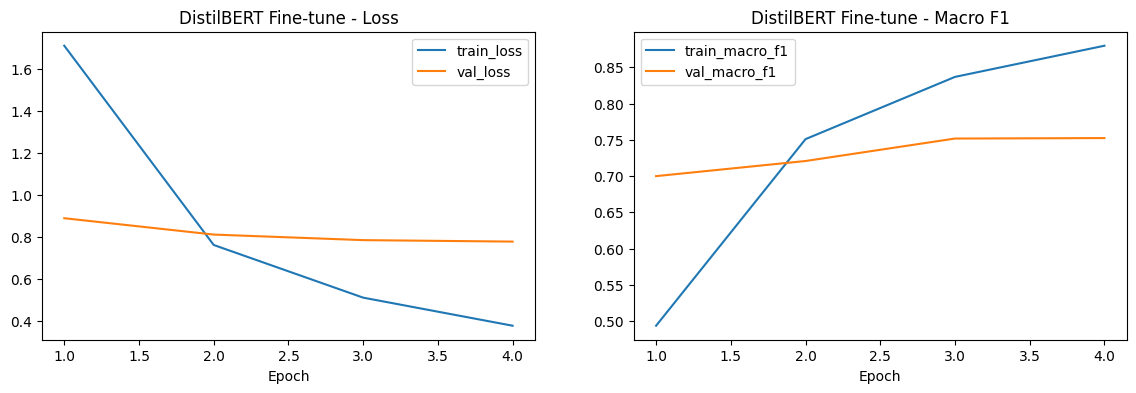

In [40]:
finetune_bert = DistilBERTClassifier(
    model_name=cfg.bert_model_name,
    num_classes=num_classes,
    dropout=cfg.bert_ft_dropout,
    freeze_backbone=False,
).to(cfg.device)

total_params, trainable_params = count_parameters(finetune_bert)
print("Fine-tune DistilBERT params:", total_params, "| trainable:", trainable_params)

ft_optimizer = torch.optim.AdamW(
    finetune_bert.parameters(),
    lr=cfg.bert_ft_lr,
    weight_decay=cfg.bert_ft_weight_decay,
)

num_training_steps = len(bert_train_loader) * cfg.bert_ft_epochs
num_warmup_steps = int(cfg.bert_warmup_ratio * num_training_steps)

ft_scheduler = get_linear_schedule_with_warmup(
    optimizer=ft_optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)

ft_ckpt_path = os.path.join(cfg.bert_ckpt_dir, "distilbert_finetune_best.pt")

finetune_bert, ft_history = fit_bert(
    model=finetune_bert,
    train_loader=bert_train_loader,
    val_loader=bert_val_loader,
    optimizer=ft_optimizer,
    criterion=criterion_bert,
    device=cfg.device,
    epochs=cfg.bert_ft_epochs,
    patience=cfg.bert_patience,
    scheduler=ft_scheduler,
    grad_clip=cfg.bert_grad_clip,
    model_name="distilbert_finetune",
    save_path=ft_ckpt_path,
)

display(ft_history)
plot_history(ft_history, title="DistilBERT Fine-tune")


### Ý nghĩa block code

Block này đánh giá DistilBERT fine-tune trên validation và test, rồi hiển thị các mẫu dự đoán sai để so sánh trực tiếp với những mô hình trước đó.



===== DistilBERT Fine-tune - VAL =====
Loss     : 0.7787
Accuracy : 0.7662
Macro F1 : 0.7525

                          precision    recall  f1-score   support

             alt.atheism     0.6292    0.5957    0.6120        94
           comp.graphics     0.7679    0.7544    0.7611       114
 comp.os.ms-windows.misc     0.7069    0.7193    0.7130       114
comp.sys.ibm.pc.hardware     0.6667    0.6897    0.6780       116
   comp.sys.mac.hardware     0.7982    0.7768    0.7873       112
          comp.windows.x     0.8509    0.8220    0.8362       118
            misc.forsale     0.7881    0.8087    0.7983       115
               rec.autos     0.8190    0.7679    0.7926       112
         rec.motorcycles     0.7982    0.7436    0.7699       117
      rec.sport.baseball     0.8870    0.8870    0.8870       115
        rec.sport.hockey     0.9074    0.8376    0.8711       117
               sci.crypt     0.8571    0.8276    0.8421       116
         sci.electronics     0.6525    0.6696 

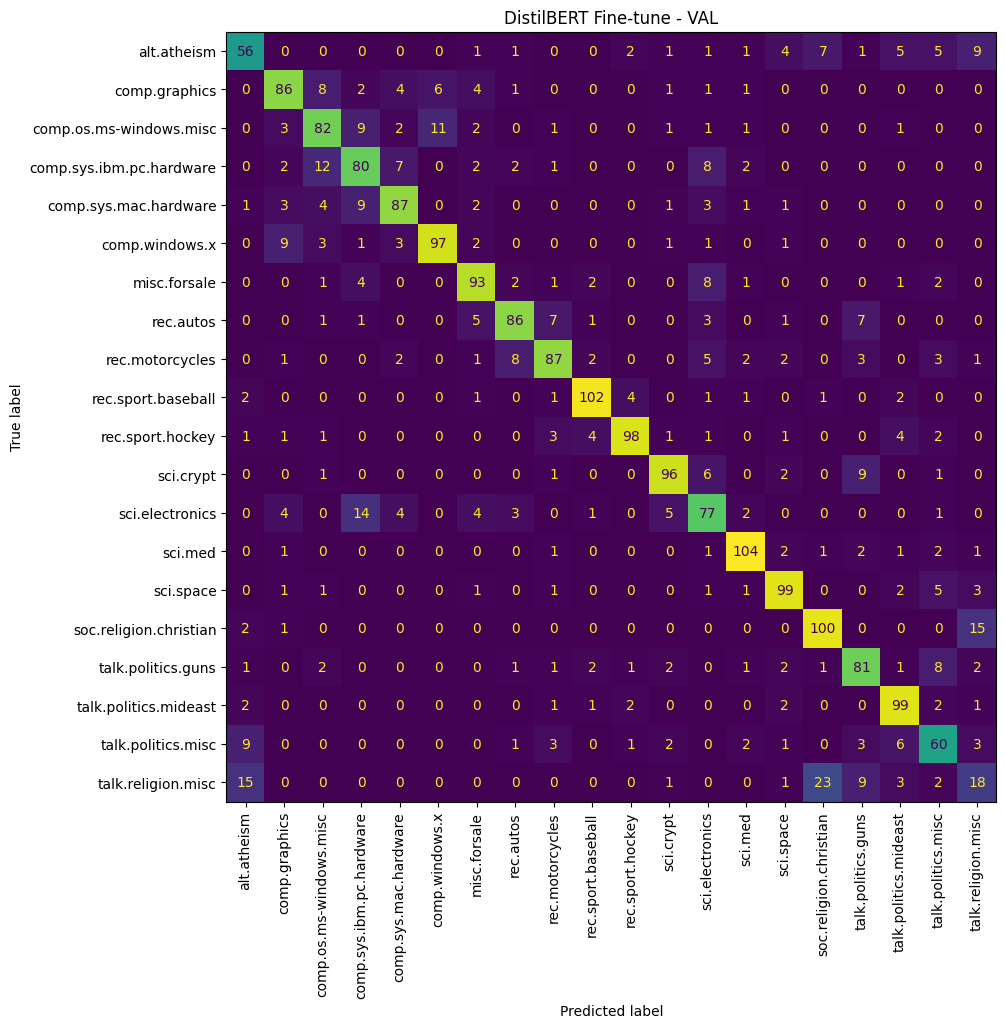

,true_id,true_label,pred_id,pred_label,confidence,text_preview
0,3,comp.sys.ibm.pc.hardware,7,rec.autos,0.466963,"Where did you get this driver. Please, please, please !!!! \tI've been waiting months for this."
1,7,rec.autos,16,talk.politics.guns,0.871851,"Place your hands flat on a table, and arrange the firing order from left to right."
2,19,talk.religion.misc,15,soc.religion.christian,0.873019,"Jesus also recognized other holy days, like the Passover. Acts 15 says that no more should be layed on the Gentiles than that which is necessary. The sabbat..."
3,12,sci.electronics,3,comp.sys.ibm.pc.hardware,0.370726,"{Kris Gleason} said ""Re: what to do with old 2"" to <All> on 04-15-93 11:02 KG> Yeah... keychains. I have seen 64K simms with a silver KG> keyring attached, ..."
4,18,talk.politics.misc,0,alt.atheism,0.593911,it may be a little late to reply to your tirade and also on an inaapropriate board but along with all of the so called great things the white male has done ...
5,19,talk.religion.misc,15,soc.religion.christian,0.618576,"But as many as received him, \tto them gave he power \tto become the sons of God, \teven to them that believe on his name:"
6,6,misc.forsale,17,talk.politics.mideast,0.229254,"Hmmm... Interesting. What do you mean by WALKING distance? I lived in Moscow for 21 years, and if I am 5 minutes walk to Belorusskaya subway station, I CANN..."
7,5,comp.windows.x,1,comp.graphics,0.301739,"My HP720 workstation uses PseudoColor (id 0x21, 255 colors) as the"
8,19,talk.religion.misc,15,soc.religion.christian,0.686830,And I think we ought to hold Christ accoountable for all of his followers who died at the hand of the Romans also. It was their own fault for believing. Go...
9,8,rec.motorcycles,18,talk.politics.misc,0.375949,"jlevine@rd.hydro.on.ca (Jody Levine) writes... \tI've already discussed this in e-mail with Jonathan. It's the film ""The Inspector General"" [:-)], with Dan..."



===== DistilBERT Fine-tune - TEST =====
Loss     : 0.9894
Accuracy : 0.7201
Macro F1 : 0.7036

                          precision    recall  f1-score   support

             alt.atheism     0.4810    0.4469    0.4633       311
           comp.graphics     0.7084    0.7214    0.7148       384
 comp.os.ms-windows.misc     0.6607    0.6834    0.6719       379
comp.sys.ibm.pc.hardware     0.6565    0.6684    0.6624       386
   comp.sys.mac.hardware     0.7162    0.7143    0.7152       371
          comp.windows.x     0.8636    0.7775    0.8183       391
            misc.forsale     0.8442    0.8508    0.8475       382
               rec.autos     0.7886    0.7760    0.7823       375
         rec.motorcycles     0.7569    0.7098    0.7326       386
      rec.sport.baseball     0.8820    0.8590    0.8704       383
        rec.sport.hockey     0.9084    0.8897    0.8990       390
               sci.crypt     0.7676    0.7474    0.7573       380
         sci.electronics     0.6150    0.6214

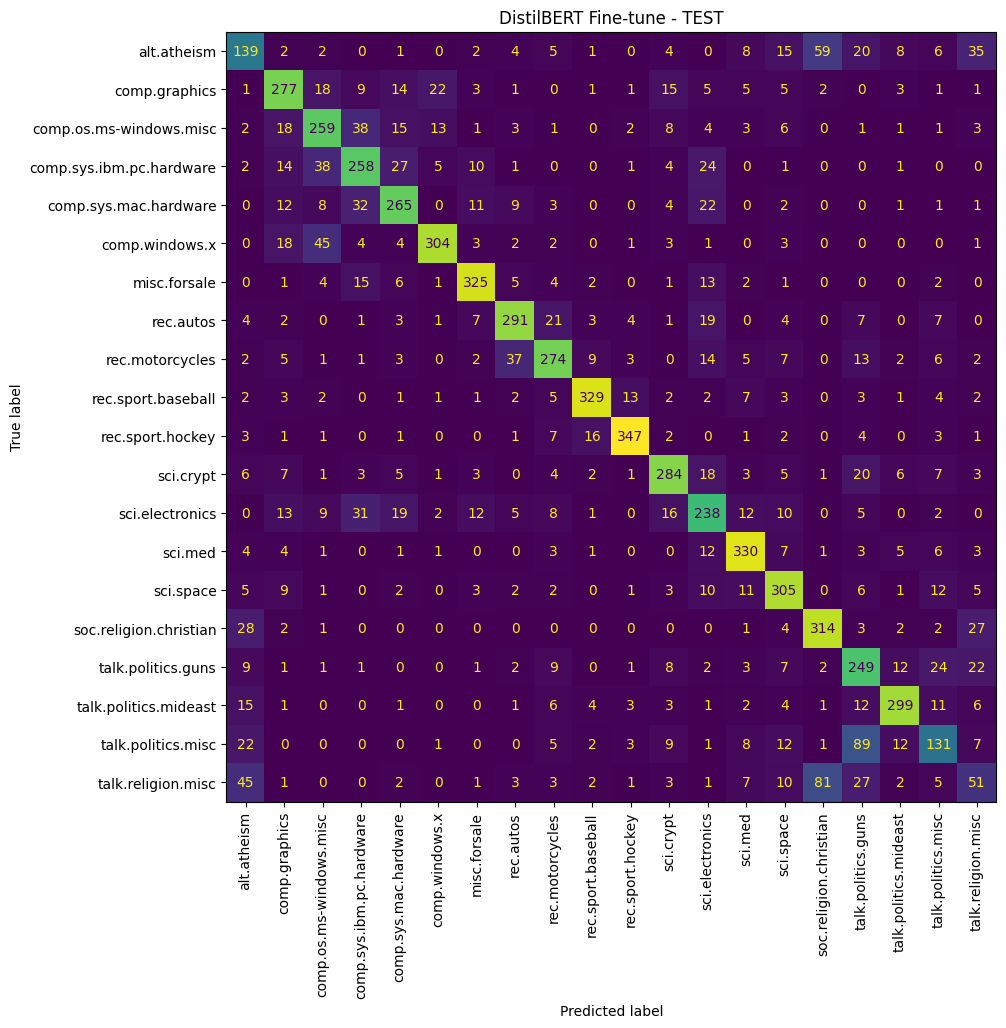

,true_id,true_label,pred_id,pred_label,confidence,text_preview
0,0,alt.atheism,17,talk.politics.mideast,0.115497,"In a word, yes."
1,19,talk.religion.misc,0,alt.atheism,0.686010,I've just spent two solid months arguing that no such thing as an objective moral system exists.
2,15,soc.religion.christian,0,alt.atheism,0.467161,"Dishonest money dwindles away, but he who gathers money little by little makes it grow. Proverbs 13:11"
3,15,soc.religion.christian,2,comp.os.ms-windows.misc,0.760030,"A friend of mine managed to get a copy of a computerised Greek and Hebrew Lexicon called ""The Word Perfect"" (That is not the word processing package WordPer..."
4,8,rec.motorcycles,16,talk.politics.guns,0.528095,"Accusation? I thought it was a recommendation. (I mean, I did grow up there, I oughta know). Bring the truck and about 10 pounds of crawfish and we'll talk."
5,0,alt.atheism,15,soc.religion.christian,0.858155,"Probably because it IS rape. So nothing. It may work for some, but not for others: it doesn't give any insight into an overall God or overall truth of a re..."
6,2,comp.os.ms-windows.misc,3,comp.sys.ibm.pc.hardware,0.954816,"From article <C68uBG.K2w@world.std.com>, by cfw@world.std.com (Christopher F Wroten): Good question. Answer: The EISA bus does move 32 bits rather than ISA'..."
7,4,comp.sys.mac.hardware,1,comp.graphics,0.348879,Iv'e got a problem printing with a StyleWriterII. I am printing from a IIvx with 20 megs ram. I am trying to print a Quark file that has 2 fonts a couple of...
8,1,comp.graphics,4,comp.sys.mac.hardware,0.538940,"Hello, i'm interested in those devices too. Could also send me your suggestions. Thank in advance. Regards. --"
9,1,comp.graphics,13,sci.med,0.343653,This is an invitation to send articles to the Informatica magazine. The first fully international issue has been published and echoes are quite favourable. ...


Fine-tune checkpoint saved to: /home/godminhkhoa/Document/Deep-Learning-Assignment/Assignment1/data/classification/text/processed/bert_checkpoints/distilbert_finetune_best.pt


In [41]:
ft_val_result = evaluate_bert(
    model=finetune_bert,
    loader=bert_val_loader,
    criterion=criterion_bert,
    device=cfg.device,
    label_names=label_names,
    title="DistilBERT Fine-tune - VAL",
)
display(ft_val_result["errors_df"])

ft_test_result = evaluate_bert(
    model=finetune_bert,
    loader=bert_test_loader,
    criterion=criterion_bert,
    device=cfg.device,
    label_names=label_names,
    title="DistilBERT Fine-tune - TEST",
)
display(ft_test_result["errors_df"])

print("Fine-tune checkpoint saved to:", ft_ckpt_path)


### Ý nghĩa block code

Block này tổng hợp bảng so sánh cuối cùng giữa TF-IDF, Mean Pooling, BiLSTM, DistilBERT frozen và DistilBERT fine-tune trên validation và test.


In [42]:
results_df_extended = pd.DataFrame([
    {
        "model": "TF-IDF + LogisticRegression",
        "val_acc": accuracy_score(y_val, val_pred_tfidf),
        "val_macro_f1": f1_score(y_val, val_pred_tfidf, average="macro"),
        "test_acc": accuracy_score(y_test, test_pred_tfidf),
        "test_macro_f1": f1_score(y_test, test_pred_tfidf, average="macro"),
    },
    {
        "model": "Embedding + MeanPooling",
        "val_acc": proto_val_result["accuracy"],
        "val_macro_f1": proto_val_result["macro_f1"],
        "test_acc": proto_test_result["accuracy"],
        "test_macro_f1": proto_test_result["macro_f1"],
    },
    {
        "model": "BiLSTM",
        "val_acc": bilstm_val_result["accuracy"],
        "val_macro_f1": bilstm_val_result["macro_f1"],
        "test_acc": bilstm_test_result["accuracy"],
        "test_macro_f1": bilstm_test_result["macro_f1"],
    },
    {
        "model": "DistilBERT Frozen",
        "val_acc": frozen_val_result["accuracy"],
        "val_macro_f1": frozen_val_result["macro_f1"],
        "test_acc": frozen_test_result["accuracy"],
        "test_macro_f1": frozen_test_result["macro_f1"],
    },
    {
        "model": "DistilBERT Fine-tune",
        "val_acc": ft_val_result["accuracy"],
        "val_macro_f1": ft_val_result["macro_f1"],
        "test_acc": ft_test_result["accuracy"],
        "test_macro_f1": ft_test_result["macro_f1"],
    },
])

display(results_df_extended.sort_values("val_macro_f1", ascending=False))


,model,val_acc,val_macro_f1,test_acc,test_macro_f1
4,DistilBERT Fine-tune,0.766228,0.752483,0.720104,0.703625
0,TF-IDF + LogisticRegression,0.750340,0.740398,0.685527,0.670120
3,DistilBERT Frozen,0.665456,0.645520,0.638786,0.619368
2,BiLSTM,0.389015,0.379054,0.337707,0.326603
1,Embedding + MeanPooling,0.410803,0.364556,0.396747,0.351003


### Ý nghĩa block code

Block này hiển thị nhanh các lỗi dự đoán của mô hình mạnh nhất hiện tại để dùng cho phần phân tích và nhận xét trong báo cáo.


In [43]:
display(ft_test_result["errors_df"])


,true_id,true_label,pred_id,pred_label,confidence,text_preview
0,0,alt.atheism,17,talk.politics.mideast,0.115497,"In a word, yes."
1,19,talk.religion.misc,0,alt.atheism,0.686010,I've just spent two solid months arguing that no such thing as an objective moral system exists.
2,15,soc.religion.christian,0,alt.atheism,0.467161,"Dishonest money dwindles away, but he who gathers money little by little makes it grow. Proverbs 13:11"
3,15,soc.religion.christian,2,comp.os.ms-windows.misc,0.760030,"A friend of mine managed to get a copy of a computerised Greek and Hebrew Lexicon called ""The Word Perfect"" (That is not the word processing package WordPer..."
4,8,rec.motorcycles,16,talk.politics.guns,0.528095,"Accusation? I thought it was a recommendation. (I mean, I did grow up there, I oughta know). Bring the truck and about 10 pounds of crawfish and we'll talk."
5,0,alt.atheism,15,soc.religion.christian,0.858155,"Probably because it IS rape. So nothing. It may work for some, but not for others: it doesn't give any insight into an overall God or overall truth of a re..."
6,2,comp.os.ms-windows.misc,3,comp.sys.ibm.pc.hardware,0.954816,"From article <C68uBG.K2w@world.std.com>, by cfw@world.std.com (Christopher F Wroten): Good question. Answer: The EISA bus does move 32 bits rather than ISA'..."
7,4,comp.sys.mac.hardware,1,comp.graphics,0.348879,Iv'e got a problem printing with a StyleWriterII. I am printing from a IIvx with 20 megs ram. I am trying to print a Quark file that has 2 fonts a couple of...
8,1,comp.graphics,4,comp.sys.mac.hardware,0.538940,"Hello, i'm interested in those devices too. Could also send me your suggestions. Thank in advance. Regards. --"
9,1,comp.graphics,13,sci.med,0.343653,This is an invitation to send articles to the Informatica magazine. The first fully international issue has been published and echoes are quite favourable. ...
